In [ ]:

import numpy as np
import scipy.io as sio
import os

base_path = r'E:\EI会议2026四月\4.2故障诊断噪声'

# ========== 1. 查看 .npz 文件 ==========
print("=" * 60)
print("【1】CWRU_48k_load_1_CNN_data.npz 文件内容")
print("=" * 60)

npz_path = os.path.join(base_path, 'CWRU_48k_load_1_CNN_data.npz')
npz_data = np.load(npz_path, allow_pickle=True)

print(f"包含的键(keys): {list(npz_data.keys())}")
print()

for key in npz_data.keys():
    arr = npz_data[key]
    print(f"  键: '{key}'")
    print(f"    类型: {type(arr)}")
    print(f"    shape: {arr.shape}")
    print(f"    dtype: {arr.dtype}")
    if arr.ndim == 1 and len(arr) <= 20:
        print(f"    内容: {arr}")
    elif arr.ndim >= 1:
        print(f"    前3个样本(如有):")
        if arr.ndim == 1:
            print(f"      {arr[:5]}")
        elif arr.ndim == 2:
            print(f"      第0行: {arr[0, :10]}...")  # 前10个值
            print(f"      min={arr.min():.6f}, max={arr.max():.6f}, mean={arr.mean():.6f}")
        elif arr.ndim == 3:
            print(f"      shape[0]样本数={arr.shape[0]}, 通道={arr.shape[1]}, 长度={arr.shape[2]}")
            print(f"      第0个样本第0通道前10值: {arr[0, 0, :10]}")
    print()

# ========== 2. 查看 raw 文件夹中的 .mat 文件 ==========
print("=" * 60)
print("【2】raw 文件夹中的 .mat 文件")
print("=" * 60)

raw_path = os.path.join(base_path, 'raw')
mat_files = sorted([f for f in os.listdir(raw_path) if f.endswith('.mat')])
print(f"共 {len(mat_files)} 个 .mat 文件: {mat_files}")
print()

for fname in mat_files:
    fpath = os.path.join(raw_path, fname)
    print(f"--- {fname} ---")
    try:
        mat = sio.loadmat(fpath)
        # 过滤掉 matlab 内部变量
        real_keys = [k for k in mat.keys() if not k.startswith('__')]
        print(f"  键(keys): {real_keys}")
        for k in real_keys:
            v = mat[k]
            print(f"    '{k}': type={type(v)}, ", end="")
            if hasattr(v, 'shape'):
                print(f"shape={v.shape}, dtype={v.dtype}")
                if v.size > 0:
                    flat = v.flatten()
                    print(f"      前5个值: {flat[:5]}")
                    print(f"      min={flat.min():.6f}, max={flat.max():.6f}")
            else:
                print(f"value={v}")
    except Exception as e:
        print(f"  读取失败: {e}")
    print()

【1】CWRU_48k_load_1_CNN_data.npz 文件内容
包含的键(keys): ['data', 'labels']

  键: 'data'
    类型: <class 'numpy.ndarray'>
    shape: (4600, 32, 32)
    dtype: float64
    前3个样本(如有):
      shape[0]样本数=4600, 通道=32, 长度=32
      第0个样本第0通道前10值: [-0.041097  -0.046104  -0.028372   0.0012517  0.033796   0.069886
  0.11724    0.16439    0.20069    0.21508  ]

  键: 'labels'
    类型: <class 'numpy.ndarray'>
    shape: (4600,)
    dtype: <U8
    前3个样本(如有):
      ['Ball_007' 'Ball_007' 'Ball_007' 'Ball_007' 'Ball_007']

【2】raw 文件夹中的 .mat 文件
共 10 个 .mat 文件: ['B007_1_123.mat', 'B014_1_190.mat', 'B021_1_227.mat', 'IR007_1_110.mat', 'IR014_1_175.mat', 'IR021_1_214.mat', 'OR007_6_1_136.mat', 'OR014_6_1_202.mat', 'OR021_6_1_239.mat', 'Time_Normal_1_098.mat']

--- B007_1_123.mat ---
  键(keys): ['X123_DE_time', 'X123_FE_time', 'X123RPM']
    'X123_DE_time': type=<class 'numpy.ndarray'>, shape=(487384, 1), dtype=float64
      前5个值: [-0.04109723 -0.046104   -0.02837169  0.00125169  0.03379569]
      min=-0.616041, max

文件名                          DE信号键                        长度        min        max
B007_1_123.mat               X123_DE_time             487384    -0.6160     0.6755
B014_1_190.mat               X190_DE_time             486224    -2.4877     2.5954
B021_1_227.mat               X227_DE_time             486804    -2.8211     2.6653
IR007_1_110.mat              X110_DE_time             486224    -1.5742     1.6516
IR014_1_175.mat              X217_DE_time             489125    -1.2083     1.3637
IR021_1_214.mat              X214_DE_time             485063    -3.1142     3.4177
OR007_6_1_136.mat            X136_DE_time             486804    -5.3636     5.3043
OR014_6_1_202.mat            X202_DE_time             484483    -1.3479     1.3694
OR021_6_1_239.mat            X239_DE_time             489125    -7.0463     7.4778
Time_Normal_1_098.mat        X098_DE_time             483903    -0.3459     0.3175


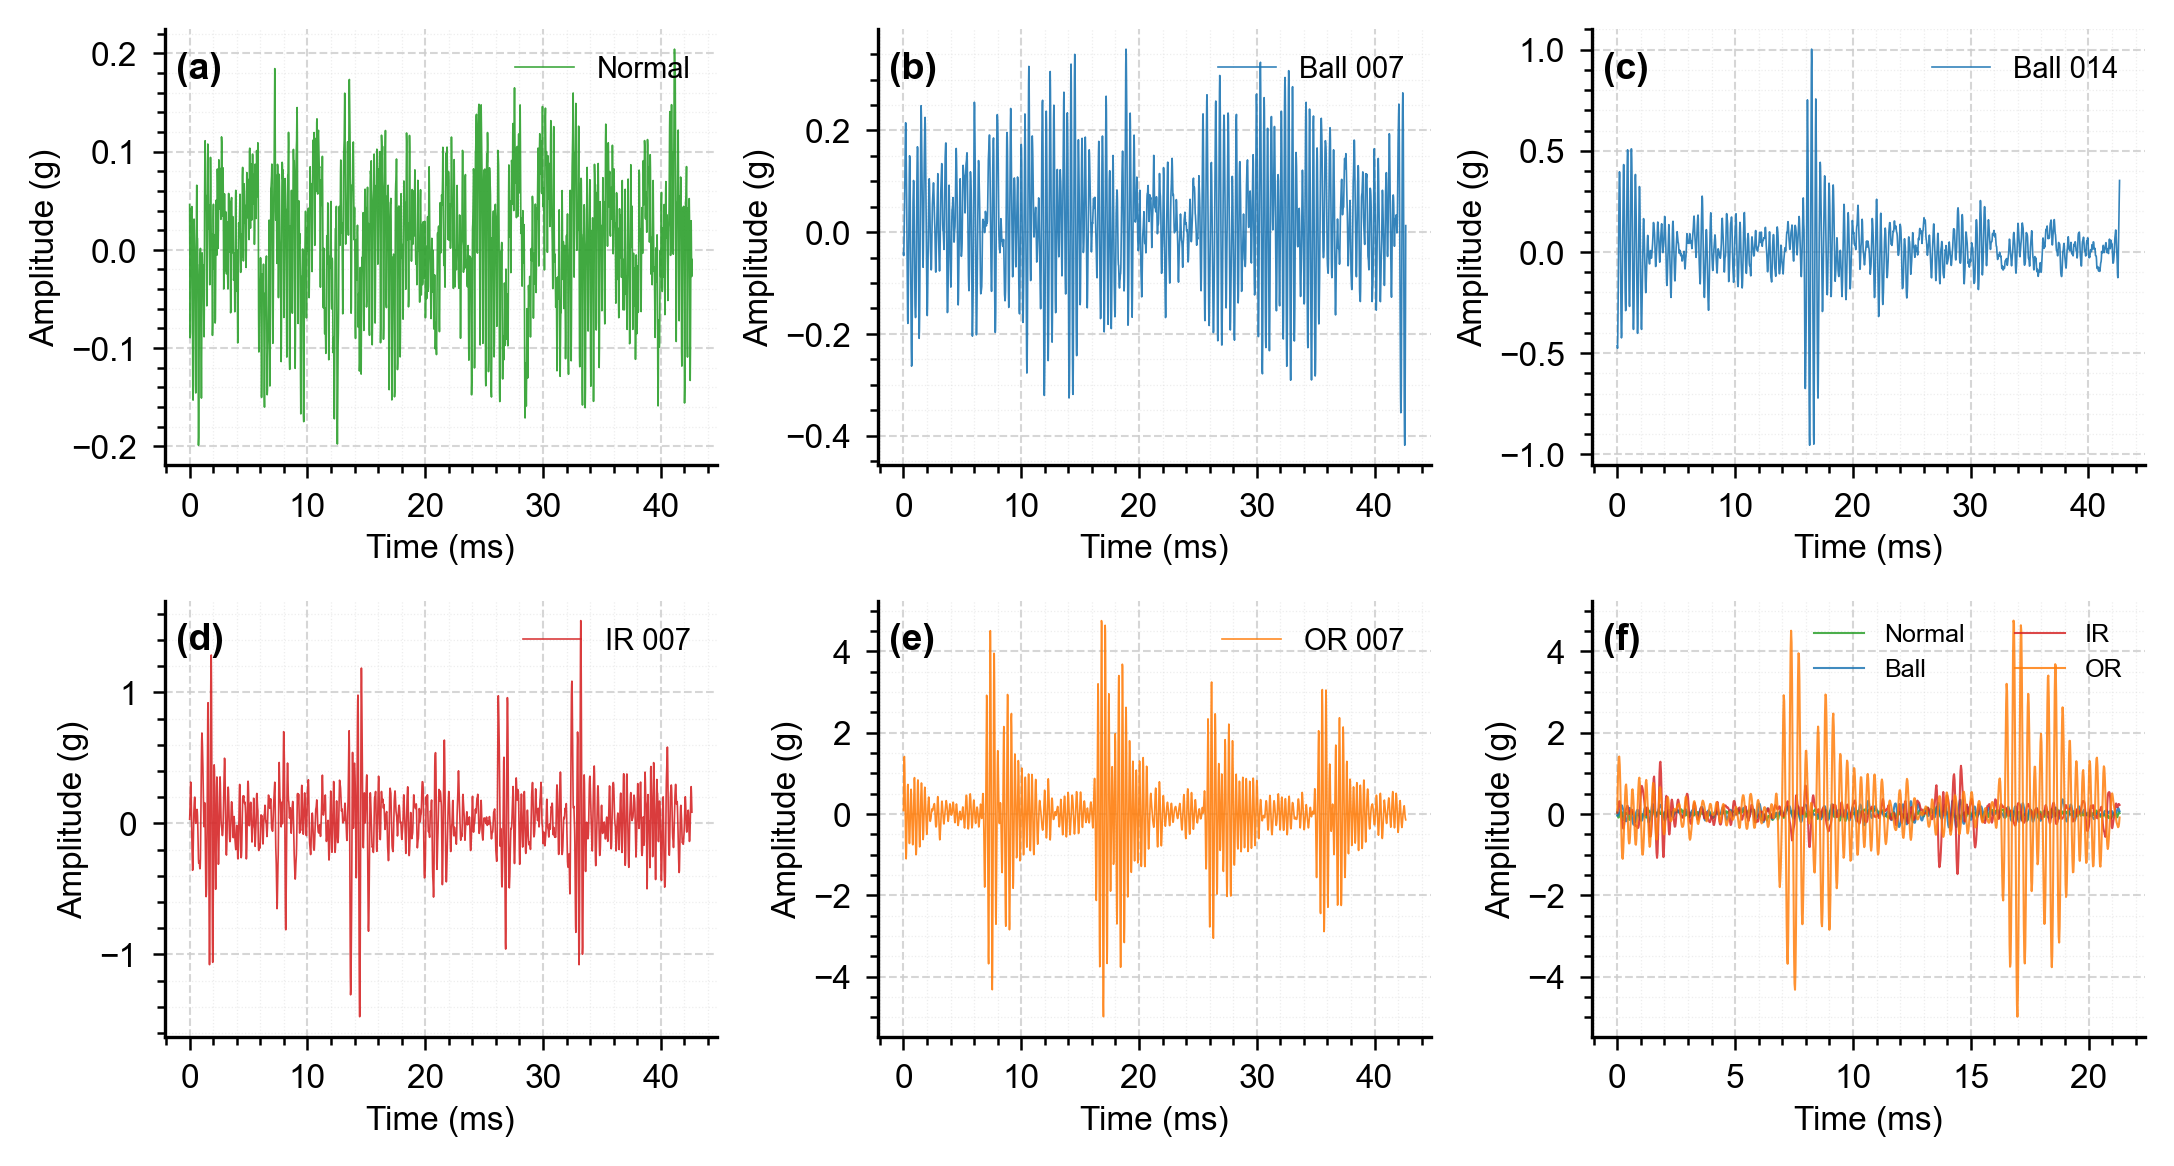

图片已保存！


In [ ]:

# 第一板块续：数据汇总 + 振动信号可视化
import numpy as np
import scipy.io as sio
import os
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.labelpad": 2.5,
    "legend.frameon": False,
    "figure.dpi": 300
})

base_path = r'E:\EI会议2026四月\4.2故障诊断噪声'
raw_path = os.path.join(base_path, 'raw')
sampling_rate = 48000  # 48kHz

# ========== 1. 加载所有 mat 并提取 DE 信号 ==========
mat_files = sorted([f for f in os.listdir(raw_path) if f.endswith('.mat')])

# 故障类型映射
fault_map = {
    'Normal': {'files': ['Time_Normal_1_098.mat'], 'label': 0, 'color': '#2ca02c'},
    'Ball':   {'files': ['B007_1_123.mat', 'B014_1_190.mat', 'B021_1_227.mat'], 'label': 1, 'color': '#1f77b4'},
    'IR':     {'files': ['IR007_1_110.mat', 'IR014_1_175.mat', 'IR021_1_214.mat'], 'label': 2, 'color': '#d62728'},
    'OR':     {'files': ['OR007_6_1_136.mat', 'OR014_6_1_202.mat', 'OR021_6_1_239.mat'], 'label': 3, 'color': '#ff7f0e'},
}

all_signals = {}
print("=" * 70)
print(f"{'文件名':<28s} {'DE信号键':<20s} {'长度':>10s} {'min':>10s} {'max':>10s}")
print("=" * 70)

for fname in mat_files:
    fpath = os.path.join(raw_path, fname)
    mat = sio.loadmat(fpath)
    real_keys = [k for k in mat.keys() if not k.startswith('__')]
    
    # 找 DE (Drive End) 加速度信号
    de_key = [k for k in real_keys if 'DE_time' in k]
    if de_key:
        sig = mat[de_key[0]].flatten()
        all_signals[fname] = sig
        print(f"{fname:<28s} {de_key[0]:<20s} {len(sig):>10d} {sig.min():>10.4f} {sig.max():>10.4f}")
    else:
        print(f"{fname:<28s} {'未找到DE信号':<20s}")

print("=" * 70)

# ========== 2. 可视化：各类故障振动信号（时域） ==========
# 布局：2行3列 — 第1行: Normal + Ball_007 + Ball_014
#                第2行: IR_007 + OR_007 + 四类对比

plot_configs = [
    ('Time_Normal_1_098.mat', 'Normal',   '#2ca02c'),
    ('B007_1_123.mat',        'Ball 007', '#1f77b4'),
    ('B014_1_190.mat',        'Ball 014', '#1f77b4'),
    ('IR007_1_110.mat',       'IR 007',   '#d62728'),
    ('OR007_6_1_136.mat',     'OR 007',   '#ff7f0e'),
]

show_points = 2048  # 展示前2048个点
t = np.arange(show_points) / sampling_rate * 1000  # 转换为 ms

fig, axes = plt.subplots(2, 3, figsize=(7.16, 3.8))
axes = axes.flatten()
labels_abc = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for i, (fname, title, color) in enumerate(plot_configs):
    ax = axes[i]
    sig = all_signals[fname][:show_points]
    ax.plot(t, sig, color=color, linewidth=0.4, alpha=0.9)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('Amplitude (g)', fontsize=8)
    
    # 半框架
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    # 网格线
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.8)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#DDDDDD', alpha=0.5)
    ax.minorticks_on()
    ax.set_axisbelow(True)
    
    # 子图标签
    ax.text(0.02, 0.95, labels_abc[i], transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')
    
    # 图例替代标题
    ax.legend([title], loc='upper right', fontsize=7, frameon=False)

# 第6个子图：四类信号叠加对比
ax = axes[5]
compare_files = [
    ('Time_Normal_1_098.mat', 'Normal',  '#2ca02c'),
    ('B007_1_123.mat',        'Ball',    '#1f77b4'),
    ('IR007_1_110.mat',       'IR',      '#d62728'),
    ('OR007_6_1_136.mat',     'OR',      '#ff7f0e'),
]
show_short = 1024
t_short = np.arange(show_short) / sampling_rate * 1000

for fname, lbl, clr in compare_files:
    sig = all_signals[fname][:show_short]
    ax.plot(t_short, sig, color=clr, linewidth=0.5, alpha=0.85, label=lbl)

ax.set_xlabel('Time (ms)', fontsize=8)
ax.set_ylabel('Amplitude (g)', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.8)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#DDDDDD', alpha=0.5)
ax.minorticks_on()
ax.set_axisbelow(True)
ax.text(0.02, 0.95, labels_abc[5], transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')
ax.legend(loc='upper right', fontsize=6, frameon=False, ncol=2)

plt.tight_layout(pad=0.5, h_pad=1.0, w_pad=0.8)

# 保存
save_path = base_path
fig.savefig(os.path.join(save_path, 'vibration_signals_overview.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(save_path, 'vibration_signals_overview.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()
print("图片已保存！")

In [3]:
# 第二板块：数据切片、DataLoader构建、加噪函数、频域可视化
import numpy as np
import scipy.io as sio
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.labelpad": 2.5,
    "legend.frameon": False,
    "figure.dpi": 300
})

base_path = r'E:\EI会议2026四月\4.2故障诊断噪声'
raw_path = os.path.join(base_path, 'raw')
sampling_rate = 48000
window_size = 1024
stride = 512  # 50%重叠

# 故障类别配置: 每类取007尺寸的故障
# 0-Normal, 1-Ball, 2-IR, 3-OR (与原代码4分类一致)
fault_config = {
    'Time_Normal_1_098.mat': {'label': 0, 'name': 'Normal'},
    'B007_1_123.mat':        {'label': 1, 'name': 'Ball'},
    'IR007_1_110.mat':       {'label': 2, 'name': 'IR'},
    'OR007_6_1_136.mat':     {'label': 3, 'name': 'OR'},
}

# 加载原始信号并切片
def load_and_slice(raw_path, fault_config, window_size, stride):
    all_samples = []
    all_labels = []
    label_names = {}
    
    for fname, cfg in fault_config.items():
        fpath = os.path.join(raw_path, fname)
        mat = sio.loadmat(fpath)
        # 找DE信号键
        de_key = [k for k in mat.keys() if 'DE_time' in k][0]
        signal = mat[de_key].flatten()
        
        # Z-score标准化(按单条信号)
        signal = (signal - np.mean(signal)) / np.std(signal)
        
        # 滑窗切片
        n_samples = (len(signal) - window_size) // stride
        for i in range(n_samples):
            start = i * stride
            segment = signal[start:start + window_size]
            all_samples.append(segment)
            all_labels.append(cfg['label'])
        
        label_names[cfg['label']] = cfg['name']
        print(f"  {cfg['name']:<8s} ({fname}): 信号长度={len(signal)}, 切出={n_samples}段")
    
    X = np.array(all_samples, dtype=np.float32)
    y = np.array(all_labels, dtype=np.int64)
    return X, y, label_names

print("加载并切片数据...")
X, y, label_names = load_and_slice(raw_path, fault_config, window_size, stride)
print(f"\n总样本数: {X.shape[0]}, 每段长度: {X.shape[1]}")
print(f"各类样本数: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"类别映射: {label_names}")


# 高斯白噪声函数
def add_gaussian_noise(signal, snr_db):
    """给信号添加指定信噪比(dB)的高斯白噪声"""
    sig_power = np.mean(signal ** 2)
    noise_power = sig_power / (10 ** (snr_db / 10))
    noise = np.random.randn(*signal.shape) * np.sqrt(noise_power)
    return signal + noise


# PyTorch Dataset
class CWRUDataset(Dataset):
    def __init__(self, X, y, snr_db=None):
        """
        X: (N, 1024) numpy array
        y: (N,) numpy array
        snr_db: 如果不为None, 训练时添加噪声
        """
        self.X = X
        self.y = y
        self.snr_db = snr_db
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx].copy()
        if self.snr_db is not None:
            x = add_gaussian_noise(x, self.snr_db)
        # 转为 (1, 1024) 形状
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.y[idx], dtype=torch.long)
        return x, label


# 划分训练集和测试集 (8:2)
np.random.seed(42)
indices = np.random.permutation(len(y))
split = int(0.8 * len(y))
train_idx, test_idx = indices[:split], indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"\n训练集: {len(X_train)}, 测试集: {len(X_test)}")

# 构建DataLoader (先不加噪, 后面训练时可以改snr_db)
batch_size = 64
train_dataset = CWRUDataset(X_train, y_train, snr_db=None)
test_dataset = CWRUDataset(X_test, y_test, snr_db=None)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 验证一下
for xb, yb in train_loader:
    print(f"\nbatch shape: x={xb.shape}, y={yb.shape}")
    print(f"x范围: [{xb.min():.4f}, {xb.max():.4f}]")
    print(f"y分布: {yb.numpy()[:10]}...")
    break

print("\nDataLoader构建完成!")

加载并切片数据...
  Normal   (Time_Normal_1_098.mat): 信号长度=483903, 切出=943段
  Ball     (B007_1_123.mat): 信号长度=487384, 切出=949段
  IR       (IR007_1_110.mat): 信号长度=486224, 切出=947段
  OR       (OR007_6_1_136.mat): 信号长度=486804, 切出=948段

总样本数: 3787, 每段长度: 1024
各类样本数: {np.int64(0): np.int64(943), np.int64(1): np.int64(949), np.int64(2): np.int64(947), np.int64(3): np.int64(948)}
类别映射: {0: 'Normal', 1: 'Ball', 2: 'IR', 3: 'OR'}

训练集: 3029, 测试集: 758

batch shape: x=torch.Size([64, 1, 1024]), y=torch.Size([64])
x范围: [-5.5437, 5.5169]
y分布: [2 2 3 0 1 3 0 0 0 0]...

DataLoader构建完成!


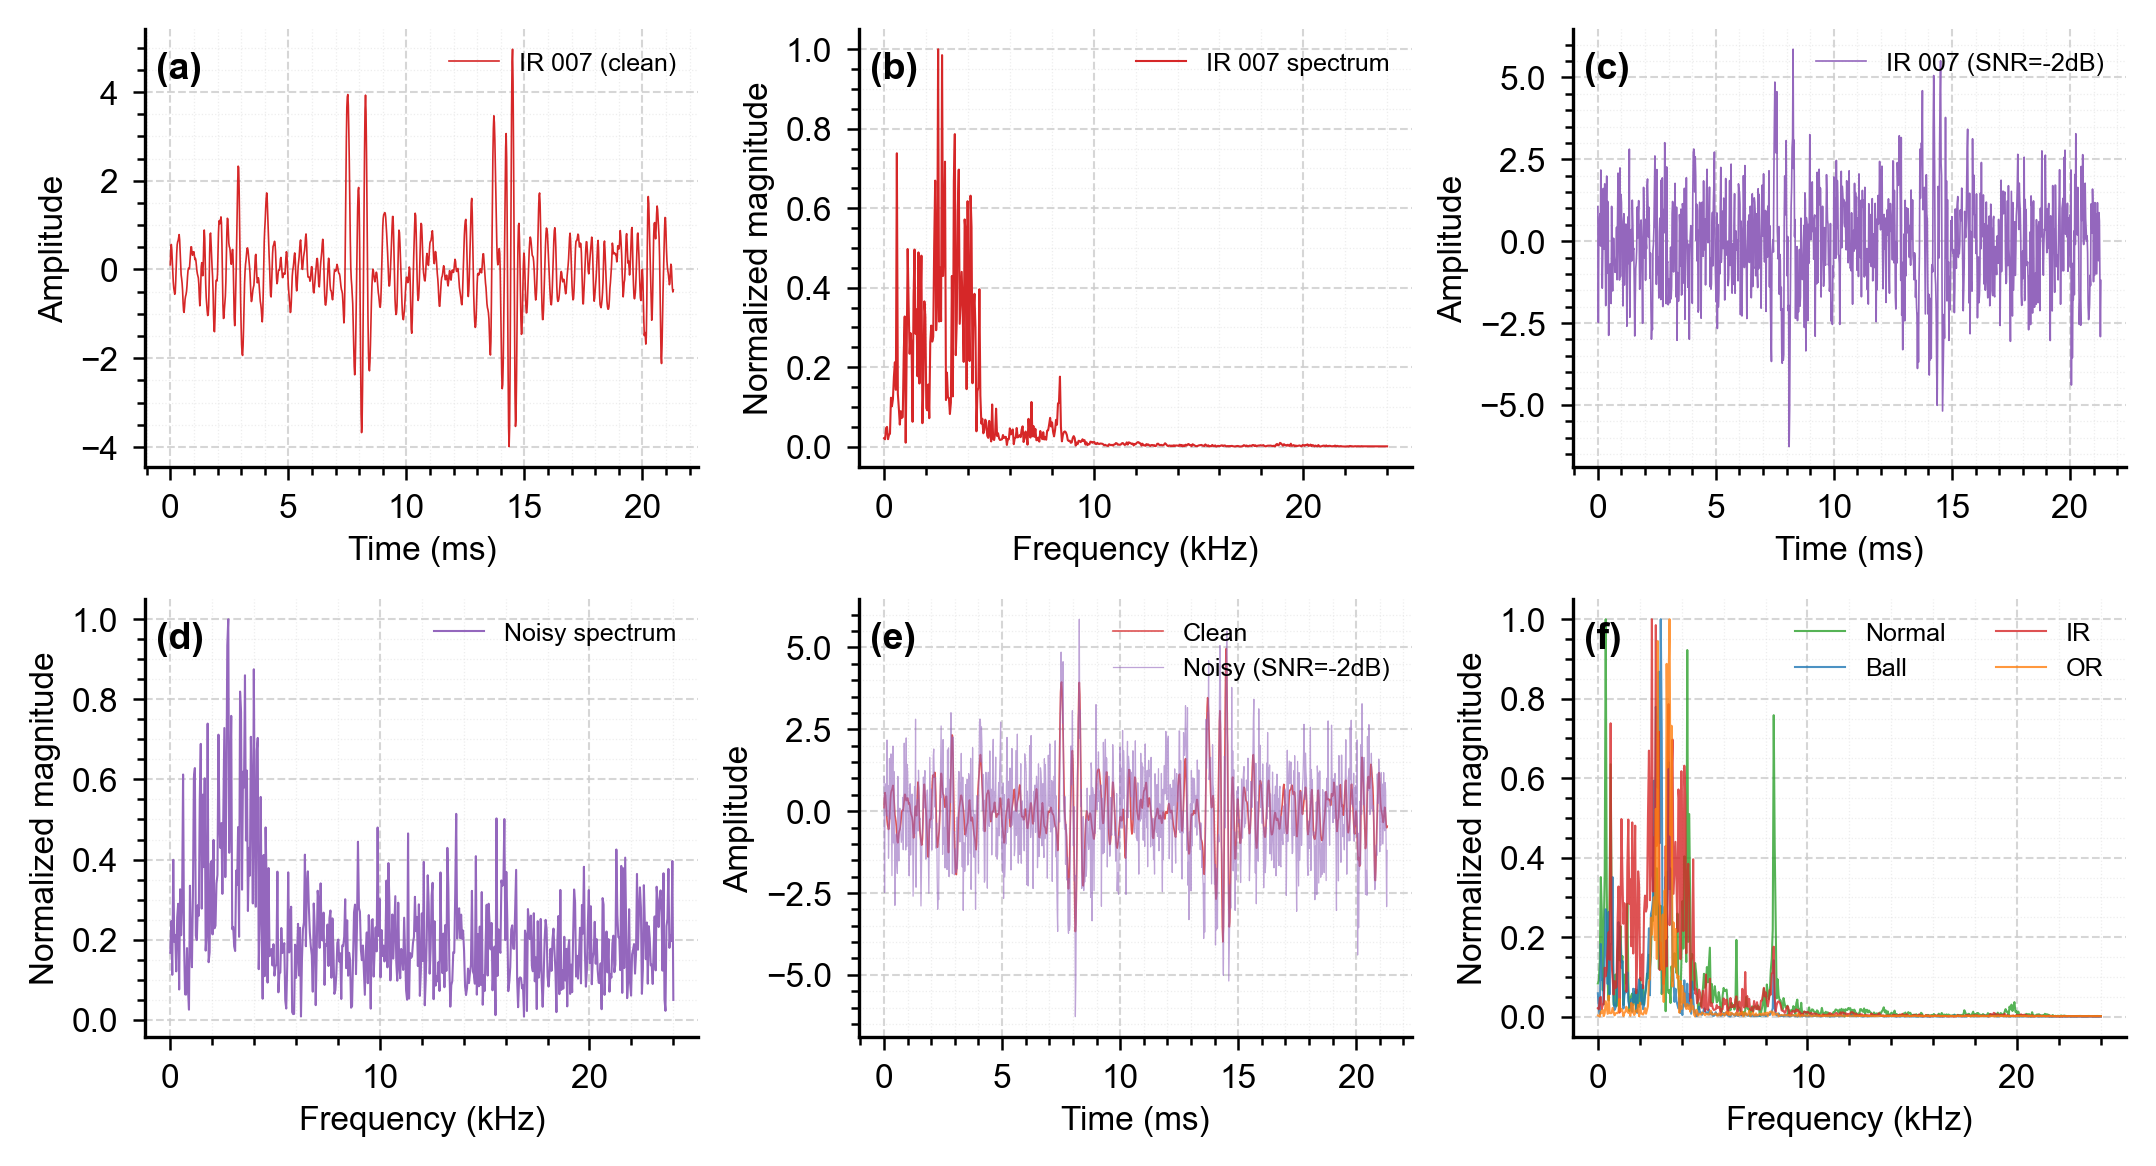

频域与加噪分析图已保存!


In [ ]:
# 第二板块续：时域-频域对比 + 加噪效果可视化
# 第1行: 原始信号时域, 原始信号频域, 加噪信号时域
# 第2行: 加噪信号频域, 噪声对比(clean vs noisy), 四类频谱对比

fig, axes = plt.subplots(2, 3, figsize=(7.16, 3.8))
axes = axes.flatten()
labels_abc = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# 取一段Normal和一段IR信号做演示
idx_normal = np.where(y_train == 0)[0][0]
idx_ir = np.where(y_train == 2)[0][0]
sig_clean = X_train[idx_ir]
sig_noisy = add_gaussian_noise(sig_clean.copy(), snr_db=-2)

t = np.arange(window_size) / sampling_rate * 1000  # ms
freq = np.fft.rfftfreq(window_size, d=1/sampling_rate) / 1000  # kHz

def setup_ax(ax, xlabel, ylabel, label_id):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.8)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#DDDDDD', alpha=0.5)
    ax.minorticks_on()
    ax.set_axisbelow(True)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.text(0.02, 0.95, label_id, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

# (a) 原始IR信号 时域
ax = axes[0]
ax.plot(t, sig_clean, color='#d62728', linewidth=0.4)
ax.legend(['IR 007 (clean)'], loc='upper right', fontsize=6)
setup_ax(ax, 'Time (ms)', 'Amplitude', labels_abc[0])

# (b) 原始IR信号 频域
ax = axes[1]
fft_clean = np.abs(np.fft.rfft(sig_clean))
fft_clean = fft_clean / fft_clean.max()  # 归一化
ax.plot(freq, fft_clean, color='#d62728', linewidth=0.5)
ax.legend(['IR 007 spectrum'], loc='upper right', fontsize=6)
setup_ax(ax, 'Frequency (kHz)', 'Normalized magnitude', labels_abc[1])

# (c) 加噪IR信号 时域 (SNR = -2dB)
ax = axes[2]
ax.plot(t, sig_noisy, color='#9467bd', linewidth=0.4)
ax.legend(['IR 007 (SNR=-2dB)'], loc='upper right', fontsize=6)
setup_ax(ax, 'Time (ms)', 'Amplitude', labels_abc[2])

# (d) 加噪IR信号 频域
ax = axes[3]
fft_noisy = np.abs(np.fft.rfft(sig_noisy))
fft_noisy = fft_noisy / fft_noisy.max()
ax.plot(freq, fft_noisy, color='#9467bd', linewidth=0.5)
ax.legend(['Noisy spectrum'], loc='upper right', fontsize=6)
setup_ax(ax, 'Frequency (kHz)', 'Normalized magnitude', labels_abc[3])

# (e) clean vs noisy 叠加对比
ax = axes[4]
ax.plot(t, sig_clean, color='#d62728', linewidth=0.4, alpha=0.8, label='Clean')
ax.plot(t, sig_noisy, color='#9467bd', linewidth=0.3, alpha=0.6, label='Noisy (SNR=-2dB)')
ax.legend(loc='upper right', fontsize=6)
setup_ax(ax, 'Time (ms)', 'Amplitude', labels_abc[4])

# (f) 四类故障频谱对比
ax = axes[5]
colors = {0: '#2ca02c', 1: '#1f77b4', 2: '#d62728', 3: '#ff7f0e'}
for cls_id in range(4):
    idx = np.where(y_train == cls_id)[0][0]
    sig = X_train[idx]
    fft_sig = np.abs(np.fft.rfft(sig))
    fft_sig = fft_sig / fft_sig.max()
    ax.plot(freq, fft_sig, color=colors[cls_id], linewidth=0.5,
            alpha=0.8, label=label_names[cls_id])
ax.legend(loc='upper right', fontsize=6, ncol=2)
setup_ax(ax, 'Frequency (kHz)', 'Normalized magnitude', labels_abc[5])

plt.tight_layout(pad=0.5, h_pad=1.0, w_pad=0.8)

fig.savefig(os.path.join(base_path, 'signal_frequency_noise_analysis.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(base_path, 'signal_frequency_noise_analysis.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()
print("频域与加噪分析图已保存!")

In [5]:
# 第三板块: EWSNet模型定义、小波初始化、Shrinkage降噪、训练与测试
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from math import pi
import time

# Laplace小波函数
def Laplace(p):
    w = 2 * pi * 80
    q = torch.tensor(1 - pow(0.03, 2))
    return 0.08 * torch.exp((-0.03 / torch.sqrt(q)) * (w * (p - 0.1))) * torch.sin(w * (p - 0.1))

# Laplace小波权重生成器(用于初始化Conv1d权重)
class Laplace_init:
    def __init__(self, out_channels, kernel_size, eps=-0.3):
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.eps = eps
        self.a_ = torch.linspace(0, out_channels, out_channels).view(-1, 1)
        self.b_ = torch.linspace(0, out_channels, out_channels).view(-1, 1)
        self.time_disc = torch.linspace(0, kernel_size - 1, steps=kernel_size)

    def forward(self):
        p1 = (self.time_disc - self.b_) / (self.a_ - self.eps)
        filters = Laplace(p1).view(self.out_channels, 1, self.kernel_size)
        return filters

# 半软阈值降噪模块(Balanced Dynamic Adaptive Threshold)
class ShrinkageModule(nn.Module):
    def __init__(self, channel, gap_size=1):
        super(ShrinkageModule, self).__init__()
        self.a = nn.Parameter(torch.tensor([0.48]))
        self.gap = nn.AdaptiveAvgPool1d(gap_size)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel),
            nn.BatchNorm1d(channel),
            nn.ReLU(inplace=True),
            nn.Linear(channel, channel),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x_raw = x
        x_abs = x.abs()
        x = self.gap(x)
        x = torch.flatten(x, 1)
        average = x
        x = self.fc(x)
        x = torch.mul(average, x).unsqueeze(2)
        # 半软阈值
        sub = torch.max(x_abs - x, torch.zeros_like(x_abs - x))
        mask = sub.clone()
        mask[mask > 0] = 1
        x = sub + (1 - self.a) * x
        x = torch.mul(torch.sign(x_raw), torch.mul(x, mask))
        return x

# EWSNet: 三流网络
class EWSNet(nn.Module):
    def __init__(self, n_class=4):
        super(EWSNet, self).__init__()
        # 第一层: 大核卷积(小波初始化)
        self.p1_0 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=250, stride=1, bias=True),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True)
        )
        # 流1: 大步长快速下采样
        self.p1_1 = nn.Sequential(
            nn.Conv1d(64, 16, kernel_size=18, stride=2, bias=True),
            nn.BatchNorm1d(16), nn.ReLU(inplace=True))
        self.p1_2 = nn.Sequential(
            nn.Conv1d(16, 10, kernel_size=10, stride=2, bias=True),
            nn.BatchNorm1d(10), nn.ReLU(inplace=True))
        self.p1_3 = nn.MaxPool1d(kernel_size=2)

        # 流2: 小核精细特征提取
        self.p2_1 = nn.Sequential(
            nn.Conv1d(64, 32, kernel_size=6, stride=1, bias=True),
            nn.BatchNorm1d(32), nn.ReLU(inplace=True))
        self.p2_2 = nn.Sequential(
            nn.Conv1d(32, 16, kernel_size=6, stride=1, bias=True),
            nn.BatchNorm1d(16), nn.ReLU(inplace=True))
        self.p2_3 = nn.MaxPool1d(kernel_size=2)
        self.p2_4 = nn.Sequential(
            nn.Conv1d(16, 10, kernel_size=6, stride=1, bias=True),
            nn.BatchNorm1d(10), nn.ReLU(inplace=True))
        self.p2_5 = nn.Sequential(
            nn.Conv1d(10, 10, kernel_size=8, stride=2, bias=True),
            nn.BatchNorm1d(10), nn.ReLU(inplace=True))
        self.p2_6 = nn.MaxPool1d(kernel_size=2)

        # 流3: Shrinkage降噪 + 卷积
        self.p3_0 = ShrinkageModule(channel=64, gap_size=1)
        self.p3_1 = nn.Sequential(
            nn.Conv1d(64, 10, kernel_size=43, stride=4, bias=True),
            nn.BatchNorm1d(10), nn.ReLU(inplace=True))
        self.p3_2 = nn.MaxPool1d(kernel_size=2)

        # 汇聚
        self.p3_3 = nn.AdaptiveAvgPool1d(1)
        self.p4 = nn.Linear(10, n_class)

        # 小波权重初始化
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                if m.kernel_size == (250,):
                    m.weight.data = Laplace_init(
                        out_channels=64, kernel_size=250).forward()
                    nn.init.constant_(m.bias.data, 0.0)
                else:
                    nn.init.kaiming_normal_(m.weight.data)
                    nn.init.constant_(m.bias.data, 0.0)
            elif isinstance(m, nn.BatchNorm1d):
                m.weight.data.fill_(1)
                m.bias.data.fill_(0)
            elif isinstance(m, nn.Linear):
                m.weight.data.normal_(0, 0.01)
                if m.bias is not None:
                    m.bias.data.fill_(0)

    def forward(self, x):
        x = self.p1_0(x)
        # 流1
        p1 = self.p1_3(self.p1_2(self.p1_1(x)))
        # 流2
        p2 = self.p2_6(self.p2_5(self.p2_4(self.p2_3(self.p2_2(self.p2_1(x))))))
        # 流3: 残差 + Shrinkage降噪
        x = self.p3_2(self.p3_1(x + self.p3_0(x)))
        # 三流融合
        x = torch.add(x, torch.add(p1, p2))
        x = self.p3_3(x).squeeze(dim=-1)
        x = self.p4(x)
        return x

# 验证模型结构
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = EWSNet(n_class=4).to(device)
test_input = torch.randn(2, 1, 1024).to(device)
test_output = model(test_input)
print(f"模型输入: {test_input.shape}")
print(f"模型输出: {test_output.shape}")
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

# Shrinkage参数a的初始值
for name, param in model.named_parameters():
    if 'p3_0.a' in name:
        print(f"Shrinkage阈值参数a初始值: {param.data.item():.4f}")

模型输入: torch.Size([2, 1, 1024])
模型输出: torch.Size([2, 4])
总参数量: 89,669
可训练参数量: 89,669
Shrinkage阈值参数a初始值: 0.4800


In [6]:
# 第三板块续: 训练循环
import torch.optim as optim

# 超参数
epochs = 100
lr = 0.001
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = EWSNet(n_class=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

# 记录训练过程
train_losses = []
train_accs = []
test_accs = []
shrinkage_a_history = []

print(f"设备: {device}")
print(f"训练集: {len(train_dataset)}, 测试集: {len(test_dataset)}")
print(f"Epochs: {epochs}, LR: {lr}, Batch: {batch_size}")
print("开始训练...\n")

for epoch in range(epochs):
    # 训练
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * xb.size(0)
        _, predicted = outputs.max(1)
        total += yb.size(0)
        correct += predicted.eq(yb).sum().item()
    
    scheduler.step()
    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # 记录Shrinkage参数a
    for name, param in model.named_parameters():
        if 'p3_0.a' in name:
            shrinkage_a_history.append(param.data.item())
    
    # 测试
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            _, predicted = outputs.max(1)
            total += yb.size(0)
            correct += predicted.eq(yb).sum().item()
    test_acc = 100.0 * correct / total
    test_accs.append(test_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}]  "
              f"Loss: {train_loss:.4f}  "
              f"Train Acc: {train_acc:.2f}%  "
              f"Test Acc: {test_acc:.2f}%  "
              f"a: {shrinkage_a_history[-1]:.4f}  "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

# 保存最终模型
save_model_path = os.path.join(base_path, 'ewsnet_cwru.pt')
torch.save(model.state_dict(), save_model_path)
print(f"\n训练完成! 模型已保存至: {save_model_path}")
print(f"最终测试精度: {test_accs[-1]:.2f}%")
print(f"最佳测试精度: {max(test_accs):.2f}% (Epoch {np.argmax(test_accs)+1})")

设备: cuda:0
训练集: 3029, 测试集: 758
Epochs: 100, LR: 0.001, Batch: 64
开始训练...

Epoch [  1/100]  Loss: 1.1090  Train Acc: 64.46%  Test Acc: 76.39%  a: 0.4796  LR: 0.001000
Epoch [ 10/100]  Loss: 0.0125  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.8144  LR: 0.000976
Epoch [ 20/100]  Loss: 0.0033  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.8852  LR: 0.000905
Epoch [ 30/100]  Loss: 0.0026  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.9407  LR: 0.000794
Epoch [ 40/100]  Loss: 0.0009  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.9611  LR: 0.000655
Epoch [ 50/100]  Loss: 0.0008  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.9759  LR: 0.000500
Epoch [ 60/100]  Loss: 0.0007  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.9864  LR: 0.000345
Epoch [ 70/100]  Loss: 0.0007  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.9929  LR: 0.000206
Epoch [ 80/100]  Loss: 0.0004  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.9917  LR: 0.000095
Epoch [ 90/100]  Loss: 0.0004  Train Acc: 100.00%  Test Acc: 100.00%  a: 0.9910  L

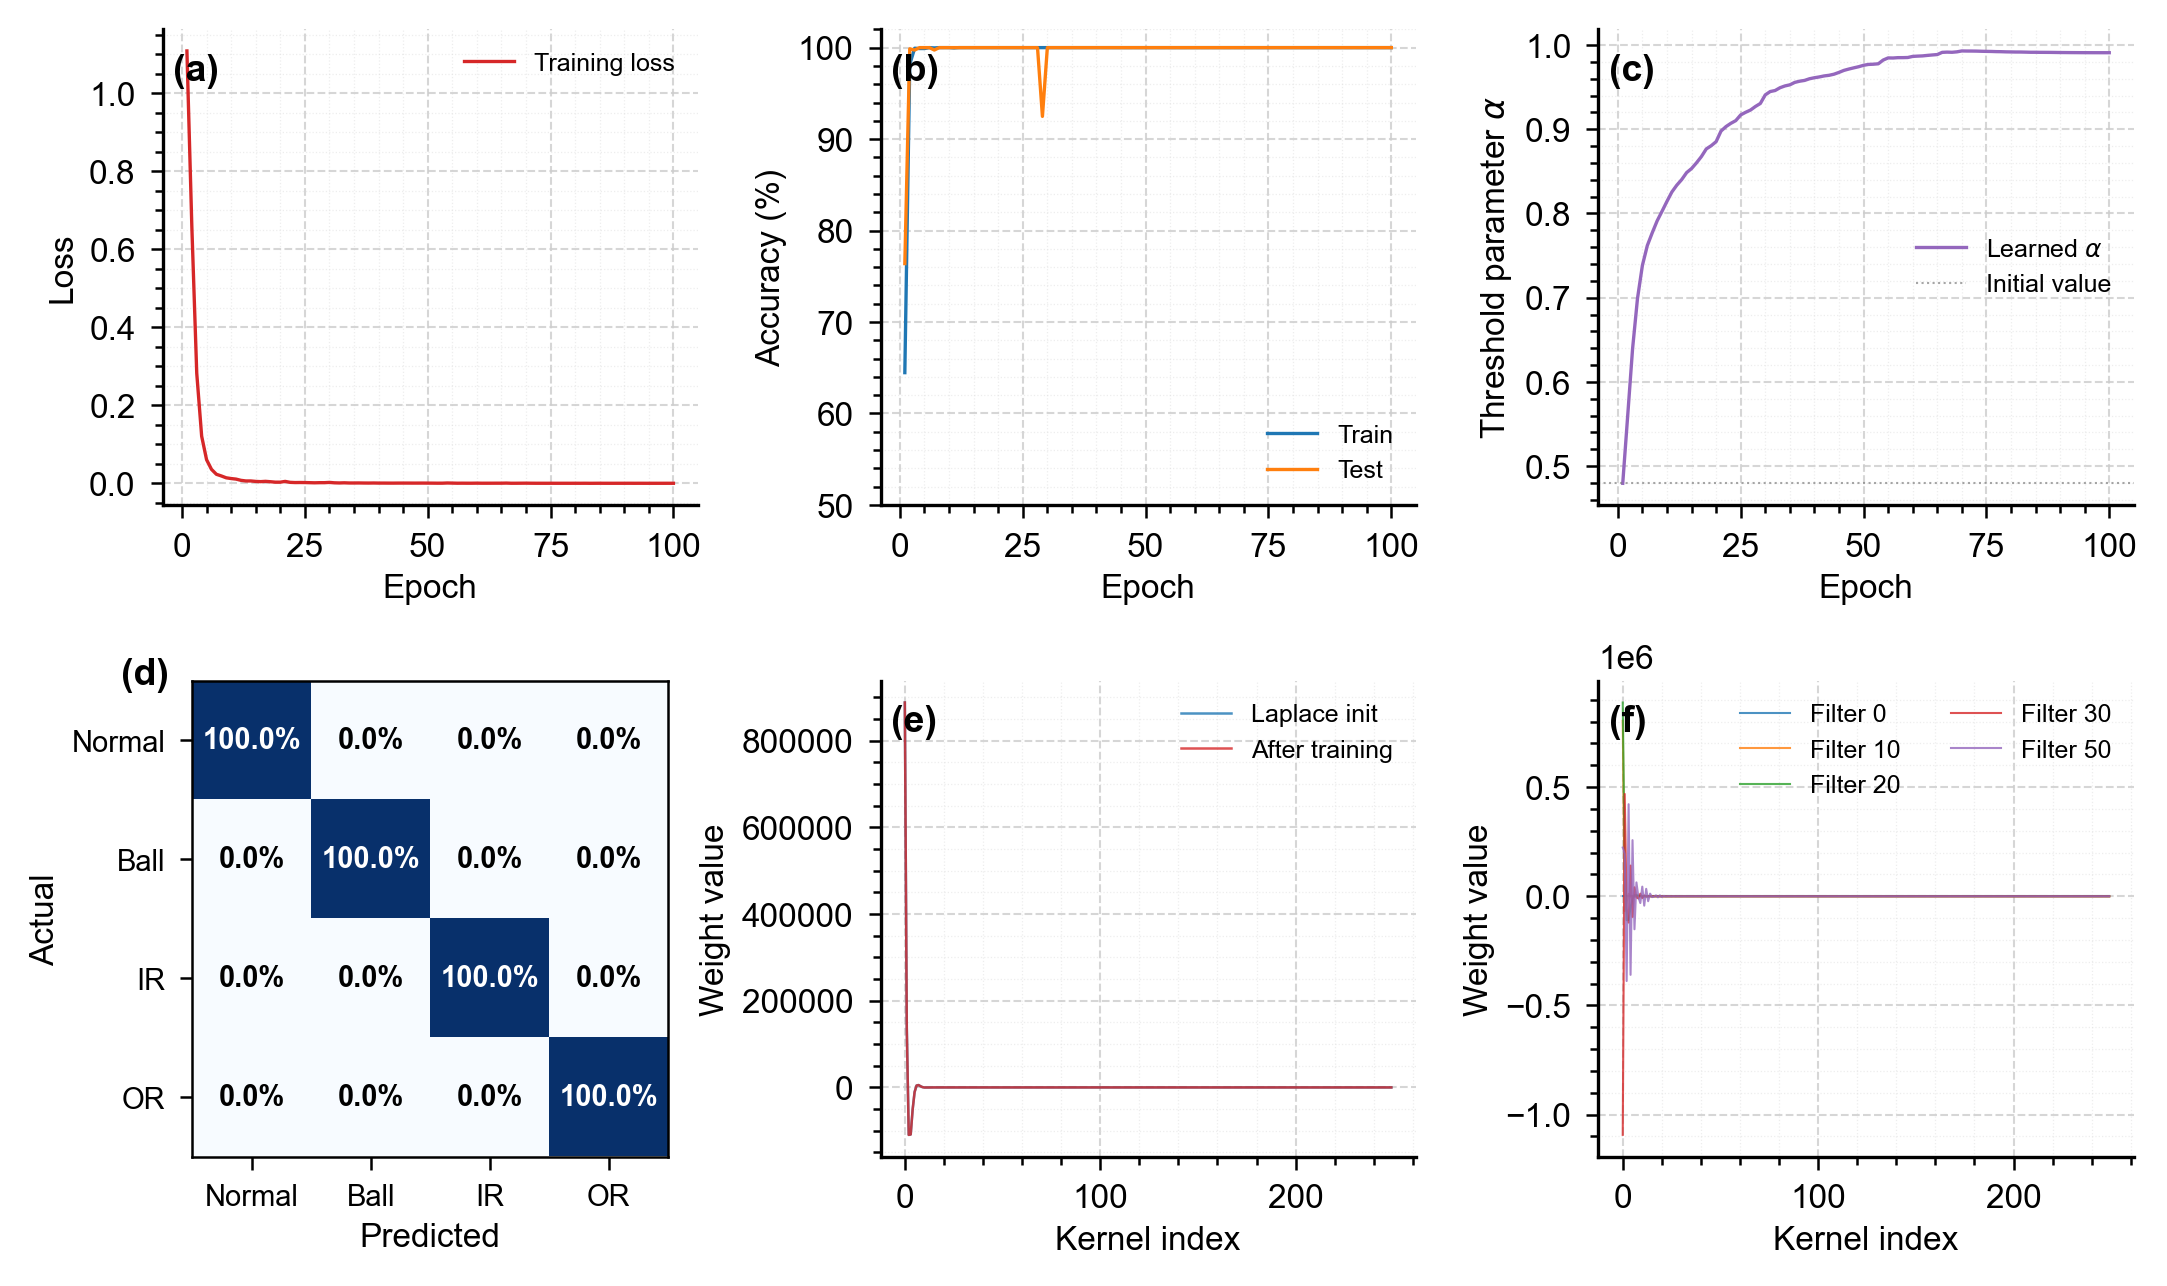

训练结果可视化已保存!


In [7]:
# 第四板块: 训练曲线、混淆矩阵、小波核可视化、Shrinkage参数演化
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import torch

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.labelpad": 2.5,
    "legend.frameon": False,
    "figure.dpi": 300
})

base_path = r'E:\EI会议2026四月\4.2故障诊断噪声'

def setup_ax(ax, xlabel, ylabel, label_id):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.8)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#DDDDDD', alpha=0.5)
    ax.minorticks_on()
    ax.set_axisbelow(True)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.text(0.02, 0.95, label_id, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

# 布局: 2行3列
fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.2))
axes_flat = axes.flatten()
labels_abc = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# (a) Loss曲线
ax = axes_flat[0]
ax.plot(range(1, len(train_losses)+1), train_losses, color='#d62728', linewidth=0.8)
setup_ax(ax, 'Epoch', 'Loss', labels_abc[0])
ax.legend(['Training loss'], loc='upper right', fontsize=6)

# (b) 准确率曲线
ax = axes_flat[1]
ax.plot(range(1, len(train_accs)+1), train_accs, color='#1f77b4', linewidth=0.8, label='Train')
ax.plot(range(1, len(test_accs)+1), test_accs, color='#ff7f0e', linewidth=0.8, label='Test')
ax.set_ylim([50, 102])
setup_ax(ax, 'Epoch', 'Accuracy (%)', labels_abc[1])
ax.legend(loc='lower right', fontsize=6)

# (c) Shrinkage参数a的演化
ax = axes_flat[2]
ax.plot(range(1, len(shrinkage_a_history)+1), shrinkage_a_history,
        color='#9467bd', linewidth=0.8)
ax.axhline(y=0.48, color='gray', linestyle=':', linewidth=0.5, alpha=0.7)
setup_ax(ax, 'Epoch', 'Threshold parameter $\\alpha$', labels_abc[2])
ax.legend(['Learned $\\alpha$', 'Initial value'], loc='center right', fontsize=6)

# (d) 混淆矩阵
ax = axes_flat[3]
model.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model(xb)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds)
class_names = ['Normal', 'Ball', 'IR', 'OR']
# 归一化到百分比
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100, aspect='equal')
for i in range(4):
    for j in range(4):
        val = cm_pct[i, j]
        color = 'white' if val > 50 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=7, color=color, fontweight='bold')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(class_names, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)
ax.set_xlabel('Predicted', fontsize=8)
ax.set_ylabel('Actual', fontsize=8)
ax.text(-0.15, 1.05, labels_abc[3], transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')

# (e) 小波初始化卷积核 vs 训练后卷积核 (选第20个滤波器)
ax = axes_flat[4]
# 初始小波核
init_weight = Laplace_init(out_channels=64, kernel_size=250).forward()
init_filter = init_weight[20, 0, :].numpy()
# 训练后的核
trained_filter = model.p1_0[0].weight.data[20, 0, :].cpu().numpy()

x_kernel = np.arange(250)
ax.plot(x_kernel, init_filter, color='#1f77b4', linewidth=0.6, alpha=0.8, label='Laplace init')
ax.plot(x_kernel, trained_filter, color='#d62728', linewidth=0.6, alpha=0.8, label='After training')
setup_ax(ax, 'Kernel index', 'Weight value', labels_abc[4])
ax.legend(loc='upper right', fontsize=6)

# (f) 多个小波初始化滤波器展示
ax = axes_flat[5]
show_indices = [0, 10, 20, 30, 50]
colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for idx, c in zip(show_indices, colors_list):
    filt = init_weight[idx, 0, :].numpy()
    ax.plot(x_kernel, filt, color=c, linewidth=0.5, alpha=0.8, label=f'Filter {idx}')
setup_ax(ax, 'Kernel index', 'Weight value', labels_abc[5])
ax.legend(loc='upper right', fontsize=6, ncol=2)

plt.tight_layout(pad=0.5, h_pad=1.2, w_pad=0.8)

fig.savefig(os.path.join(base_path, 'training_results_overview.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(base_path, 'training_results_overview.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()
print("训练结果可视化已保存!")

噪声鲁棒性测试:
SNR (dB)     Accuracy (%)   
    10 dB     22.82%
     6 dB     22.56%
     4 dB     22.56%
     2 dB     22.56%
     0 dB     22.56%
    -2 dB     22.56%
    -4 dB     22.56%
    -6 dB     22.56%


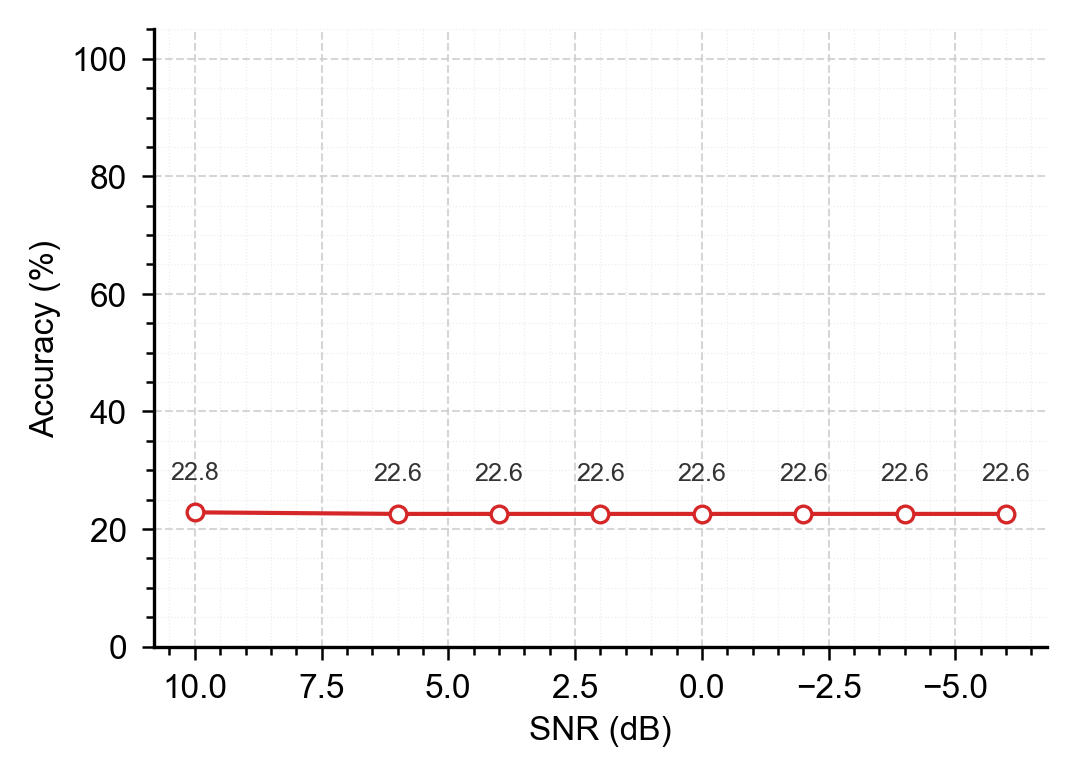

噪声鲁棒性图已保存!


In [8]:
# 第四板块续: 噪声鲁棒性实验 - 不同SNR下的测试精度
snr_list = [10, 6, 4, 2, 0, -2, -4, -6]
snr_results = {}

model.eval()
print("噪声鲁棒性测试:")
print(f"{'SNR (dB)':<12s} {'Accuracy (%)':<15s}")

for snr in snr_list:
    # 构建加噪测试集
    noisy_test = CWRUDataset(X_test, y_test, snr_db=snr)
    noisy_loader = DataLoader(noisy_test, batch_size=batch_size, shuffle=False)
    
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in noisy_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            _, predicted = outputs.max(1)
            total += yb.size(0)
            correct += predicted.eq(yb).sum().item()
    
    acc = 100.0 * correct / total
    snr_results[snr] = acc
    print(f"{snr:>6d} dB     {acc:.2f}%")

# 可视化噪声鲁棒性
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5))

snr_vals = list(snr_results.keys())
acc_vals = list(snr_results.values())

ax.plot(snr_vals, acc_vals, 'o-', color='#d62728', linewidth=1.0,
        markersize=4, markerfacecolor='white', markeredgewidth=0.8)

# 在每个点标注数值
for s, a in zip(snr_vals, acc_vals):
    ax.annotate(f'{a:.1f}', (s, a), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=6, color='#333333')

setup_ax(ax, 'SNR (dB)', 'Accuracy (%)', '')
ax.set_ylim([0, 105])
ax.invert_xaxis()  # SNR从高到低

plt.tight_layout(pad=0.5)
fig.savefig(os.path.join(base_path, 'noise_robustness.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(base_path, 'noise_robustness.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()
print("噪声鲁棒性图已保存!")

In [9]:
# 第四板块修正: 加噪训练, 提升噪声鲁棒性
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

base_path = r'E:\EI会议2026四月\4.2故障诊断噪声'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 重新构建加噪训练集 (训练时SNR=0dB)
train_dataset_noisy = CWRUDataset(X_train, y_train, snr_db=0)
train_loader_noisy = DataLoader(train_dataset_noisy, batch_size=64, shuffle=True, drop_last=True)

# 干净测试集
test_dataset_clean = CWRUDataset(X_test, y_test, snr_db=None)
test_loader_clean = DataLoader(test_dataset_clean, batch_size=64, shuffle=False)

# 重新初始化模型
model2 = EWSNet(n_class=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

epochs = 150
train_losses2 = []
train_accs2 = []
test_accs2 = []
shrinkage_a2 = []

print("加噪训练 (训练时SNR=0dB, 测试用干净数据)")
print(f"设备: {device}, Epochs: {epochs}\n")

for epoch in range(epochs):
    model2.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for xb, yb in train_loader_noisy:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs = model2(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * xb.size(0)
        _, predicted = outputs.max(1)
        total += yb.size(0)
        correct += predicted.eq(yb).sum().item()
    
    scheduler.step()
    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    train_losses2.append(train_loss)
    train_accs2.append(train_acc)
    
    for name, param in model2.named_parameters():
        if 'p3_0.a' in name:
            shrinkage_a2.append(param.data.item())
    
    model2.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader_clean:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model2(xb)
            _, predicted = outputs.max(1)
            total += yb.size(0)
            correct += predicted.eq(yb).sum().item()
    test_acc = 100.0 * correct / total
    test_accs2.append(test_acc)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}]  "
              f"Loss: {train_loss:.4f}  "
              f"Train Acc: {train_acc:.2f}%  "
              f"Test Acc: {test_acc:.2f}%  "
              f"a: {shrinkage_a2[-1]:.4f}  "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

torch.save(model2.state_dict(), os.path.join(base_path, 'ewsnet_cwru_noisy.pt'))
print(f"\n训练完成! 最终测试精度: {test_accs2[-1]:.2f}%")
print(f"最佳测试精度: {max(test_accs2):.2f}% (Epoch {np.argmax(test_accs2)+1})")

加噪训练 (训练时SNR=0dB, 测试用干净数据)
设备: cuda:0, Epochs: 150

Epoch [  1/150]  Loss: 1.2366  Train Acc: 59.57%  Test Acc: 59.63%  a: 0.4969  LR: 0.001000
Epoch [ 10/150]  Loss: 0.0425  Train Acc: 99.60%  Test Acc: 79.82%  a: 0.8097  LR: 0.000989
Epoch [ 20/150]  Loss: 0.0157  Train Acc: 99.77%  Test Acc: 87.47%  a: 0.8837  LR: 0.000957
Epoch [ 30/150]  Loss: 0.0077  Train Acc: 99.87%  Test Acc: 92.35%  a: 0.9472  LR: 0.000905
Epoch [ 40/150]  Loss: 0.0056  Train Acc: 99.93%  Test Acc: 82.32%  a: 0.9992  LR: 0.000835
Epoch [ 50/150]  Loss: 0.0060  Train Acc: 99.97%  Test Acc: 78.50%  a: 1.0612  LR: 0.000750
Epoch [ 60/150]  Loss: 0.0023  Train Acc: 100.00%  Test Acc: 96.97%  a: 1.1031  LR: 0.000655
Epoch [ 70/150]  Loss: 0.0022  Train Acc: 100.00%  Test Acc: 99.21%  a: 1.1277  LR: 0.000552
Epoch [ 80/150]  Loss: 0.0019  Train Acc: 99.97%  Test Acc: 97.23%  a: 1.1500  LR: 0.000448
Epoch [ 90/150]  Loss: 0.0009  Train Acc: 100.00%  Test Acc: 98.68%  a: 1.1686  LR: 0.000345
Epoch [100/150]  Loss: 0.

In [10]:
# 噪声鲁棒性重测(用加噪训练的model2)
snr_list = [10, 6, 4, 2, 0, -2, -4, -6]
snr_results2 = {}

model2.eval()
print("噪声鲁棒性测试 (加噪训练后):")
print(f"{'SNR (dB)':<12s} {'Accuracy (%)':<15s}")

# 无噪声测试
correct = 0
total = 0
with torch.no_grad():
    for xb, yb in test_loader_clean:
        xb, yb = xb.to(device), yb.to(device)
        outputs = model2(xb)
        _, predicted = outputs.max(1)
        total += yb.size(0)
        correct += predicted.eq(yb).sum().item()
snr_results2['clean'] = 100.0 * correct / total
print(f"{'clean':<12s} {snr_results2['clean']:.2f}%")

for snr in snr_list:
    noisy_test = CWRUDataset(X_test, y_test, snr_db=snr)
    noisy_loader = DataLoader(noisy_test, batch_size=64, shuffle=False)
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in noisy_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model2(xb)
            _, predicted = outputs.max(1)
            total += yb.size(0)
            correct += predicted.eq(yb).sum().item()
    acc = 100.0 * correct / total
    snr_results2[snr] = acc
    print(f"{snr:>6d} dB     {acc:.2f}%")

噪声鲁棒性测试 (加噪训练后):
SNR (dB)     Accuracy (%)   
clean        99.87%
    10 dB     99.87%
     6 dB     99.87%
     4 dB     100.00%
     2 dB     100.00%
     0 dB     100.00%
    -2 dB     100.00%
    -4 dB     99.08%
    -6 dB     81.13%


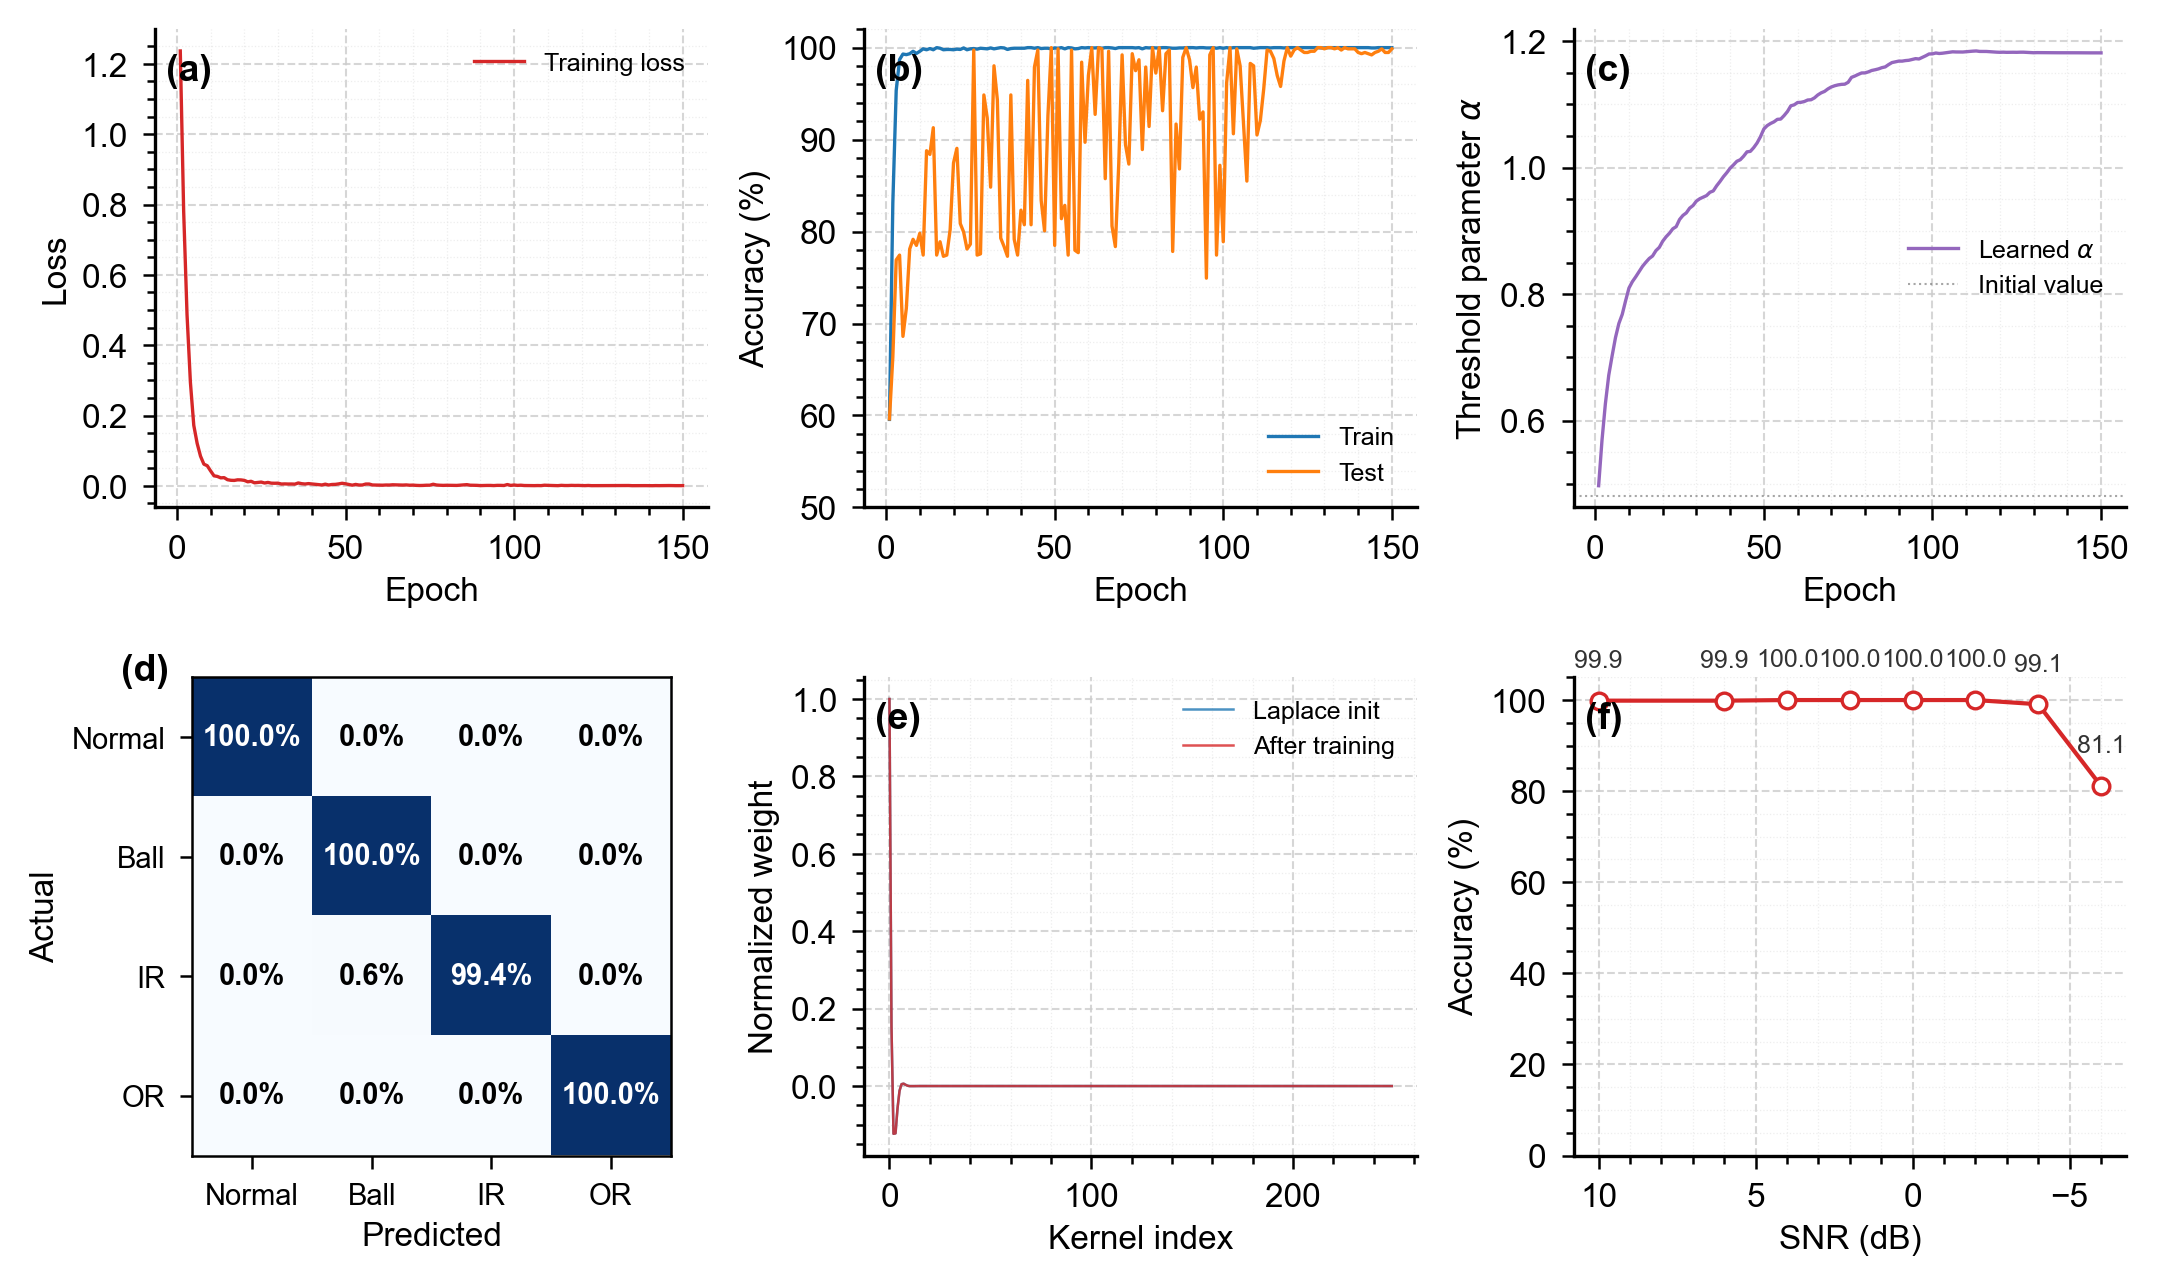

修正后的结果可视化已保存!


In [11]:
# 完整结果可视化: 2行3列
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.labelpad": 2.5,
    "legend.frameon": False,
    "figure.dpi": 300
})

def setup_ax(ax, xlabel, ylabel, label_id):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.8)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#DDDDDD', alpha=0.5)
    ax.minorticks_on()
    ax.set_axisbelow(True)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.text(0.02, 0.95, label_id, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.2))
axes_flat = axes.flatten()
labels_abc = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# (a) Loss
ax = axes_flat[0]
ax.plot(range(1, len(train_losses2)+1), train_losses2, color='#d62728', linewidth=0.8)
setup_ax(ax, 'Epoch', 'Loss', labels_abc[0])
ax.legend(['Training loss'], loc='upper right', fontsize=6)

# (b) Accuracy
ax = axes_flat[1]
ax.plot(range(1, len(train_accs2)+1), train_accs2, color='#1f77b4', linewidth=0.8, label='Train')
ax.plot(range(1, len(test_accs2)+1), test_accs2, color='#ff7f0e', linewidth=0.8, label='Test')
ax.set_ylim([50, 102])
setup_ax(ax, 'Epoch', 'Accuracy (%)', labels_abc[1])
ax.legend(loc='lower right', fontsize=6)

# (c) Shrinkage alpha
ax = axes_flat[2]
ax.plot(range(1, len(shrinkage_a2)+1), shrinkage_a2, color='#9467bd', linewidth=0.8)
ax.axhline(y=0.48, color='gray', linestyle=':', linewidth=0.5, alpha=0.7)
setup_ax(ax, 'Epoch', 'Threshold parameter $\\alpha$', labels_abc[2])
ax.legend(['Learned $\\alpha$', 'Initial value'], loc='center right', fontsize=6)

# (d) 混淆矩阵
ax = axes_flat[3]
model2.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for xb, yb in test_loader_clean:
        xb = xb.to(device)
        outputs = model2(xb)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds)
class_names = ['Normal', 'Ball', 'IR', 'OR']
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100, aspect='equal')
for i in range(4):
    for j in range(4):
        val = cm_pct[i, j]
        color = 'white' if val > 50 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=7, color=color, fontweight='bold')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(class_names, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)
ax.set_xlabel('Predicted', fontsize=8)
ax.set_ylabel('Actual', fontsize=8)
ax.text(-0.15, 1.05, labels_abc[3], transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')

# (e) 小波核对比 (归一化展示)
ax = axes_flat[4]
init_weight = Laplace_init(out_channels=64, kernel_size=250).forward()
init_filter = init_weight[20, 0, :].numpy()
trained_filter = model2.p1_0[0].weight.data[20, 0, :].cpu().numpy()

# 归一化到[-1, 1]方便对比形态
init_norm = init_filter / (np.abs(init_filter).max() + 1e-8)
trained_norm = trained_filter / (np.abs(trained_filter).max() + 1e-8)

x_kernel = np.arange(250)
ax.plot(x_kernel, init_norm, color='#1f77b4', linewidth=0.6, alpha=0.8, label='Laplace init')
ax.plot(x_kernel, trained_norm, color='#d62728', linewidth=0.6, alpha=0.8, label='After training')
setup_ax(ax, 'Kernel index', 'Normalized weight', labels_abc[4])
ax.legend(loc='upper right', fontsize=6)

# (f) 噪声鲁棒性曲线
ax = axes_flat[5]
snr_plot = [s for s in snr_list]
acc_plot = [snr_results2[s] for s in snr_list]

ax.plot(snr_plot, acc_plot, 'o-', color='#d62728', linewidth=1.0,
        markersize=4, markerfacecolor='white', markeredgewidth=0.8)
for s, a in zip(snr_plot, acc_plot):
    ax.annotate(f'{a:.1f}', (s, a), textcoords="offset points",
                xytext=(0, 8), ha='center', fontsize=6, color='#333333')
setup_ax(ax, 'SNR (dB)', 'Accuracy (%)', labels_abc[5])
ax.set_ylim([0, 105])
ax.invert_xaxis()

plt.tight_layout(pad=0.5, h_pad=1.2, w_pad=0.8)

fig.savefig(os.path.join(base_path, 'training_results_noisy_v2.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(base_path, 'training_results_noisy_v2.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()
print("修正后的结果可视化已保存!")

干净特征: (758, 10), 加噪特征: (758, 10)
正在计算t-SNE (干净数据)...
正在计算t-SNE (SNR=-4dB)...
t-SNE完成!


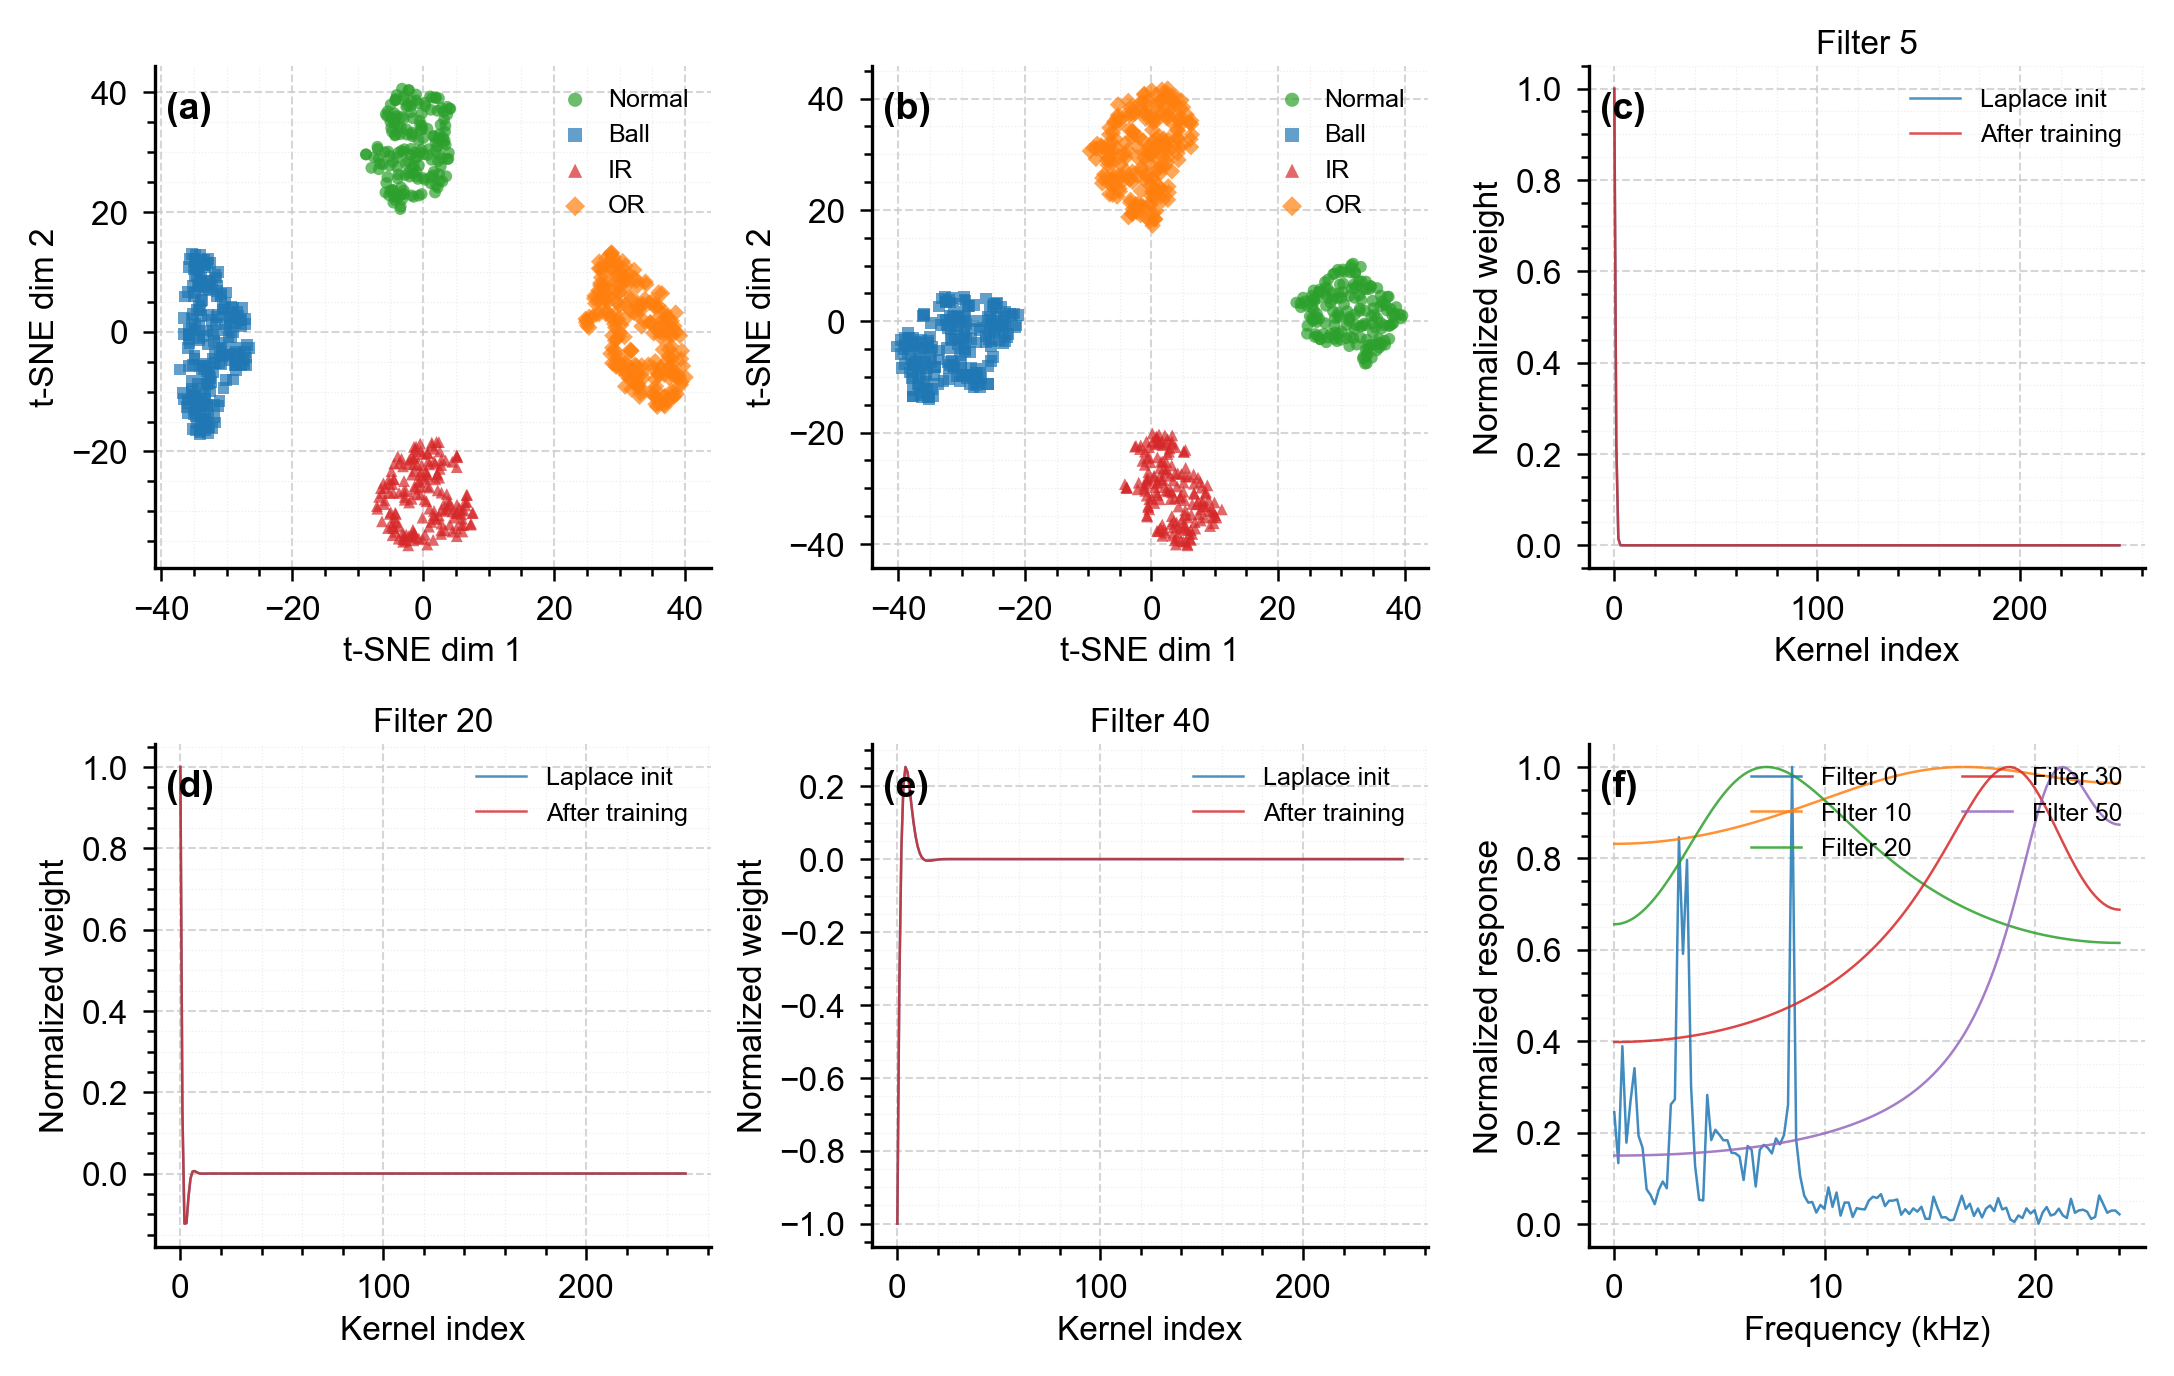

t-SNE与小波核分析图已保存!


In [12]:
# 第五板块: t-SNE特征可视化 + 小波核形态对比
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.labelpad": 2.5,
    "legend.frameon": False,
    "figure.dpi": 300
})

base_path = r'E:\EI会议2026四月\4.2故障诊断噪声'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def setup_ax(ax, xlabel, ylabel, label_id):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.8)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#DDDDDD', alpha=0.5)
    ax.minorticks_on()
    ax.set_axisbelow(True)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.text(0.02, 0.95, label_id, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

# 提取中间特征的hook
class FeatureExtractor:
    def __init__(self, model):
        self.model = model
        self.features = {}
    
    def extract(self, x):
        """提取三流融合后、全局池化前的特征和最终logits前的特征"""
        with torch.no_grad():
            x = self.model.p1_0(x)
            p1 = self.model.p1_3(self.model.p1_2(self.model.p1_1(x)))
            p2 = self.model.p2_6(self.model.p2_5(self.model.p2_4(
                self.model.p2_3(self.model.p2_2(self.model.p2_1(x))))))
            x_shrink = self.model.p3_2(self.model.p3_1(x + self.model.p3_0(x)))
            fused = torch.add(x_shrink, torch.add(p1, p2))
            pooled = self.model.p3_3(fused).squeeze(dim=-1)  # (B, 10)
            logits = self.model.p4(pooled)
        return pooled, logits

# 提取测试集特征 (干净)
extractor = FeatureExtractor(model2)
model2.eval()

feats_clean = []
labels_clean = []
for xb, yb in test_loader_clean:
    xb = xb.to(device)
    pooled, _ = extractor.extract(xb)
    feats_clean.append(pooled.cpu().numpy())
    labels_clean.append(yb.numpy())

feats_clean = np.concatenate(feats_clean, axis=0)
labels_clean = np.concatenate(labels_clean, axis=0)

# 提取测试集特征 (SNR=-4dB)
noisy_test_m4 = CWRUDataset(X_test, y_test, snr_db=-4)
noisy_loader_m4 = DataLoader(noisy_test_m4, batch_size=64, shuffle=False)

feats_noisy = []
labels_noisy = []
for xb, yb in noisy_loader_m4:
    xb = xb.to(device)
    pooled, _ = extractor.extract(xb)
    feats_noisy.append(pooled.cpu().numpy())
    labels_noisy.append(yb.numpy())

feats_noisy = np.concatenate(feats_noisy, axis=0)
labels_noisy = np.concatenate(labels_noisy, axis=0)

print(f"干净特征: {feats_clean.shape}, 加噪特征: {feats_noisy.shape}")

# t-SNE降维
print("正在计算t-SNE (干净数据)...")
tsne_clean = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(feats_clean)
print("正在计算t-SNE (SNR=-4dB)...")
tsne_noisy = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(feats_noisy)
print("t-SNE完成!")

# 可视化: 2行3列
# (a) t-SNE干净  (b) t-SNE加噪  (c) 小波核初始化vs训练后 filter 5
# (d) filter 20  (e) filter 40  (f) 多个训练后滤波器叠加

fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.5))
axes_flat = axes.flatten()
labels_abc = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
class_names = ['Normal', 'Ball', 'IR', 'OR']
colors = {0: '#2ca02c', 1: '#1f77b4', 2: '#d62728', 3: '#ff7f0e'}
markers = {0: 'o', 1: 's', 2: '^', 3: 'D'}

# (a) t-SNE 干净数据
ax = axes_flat[0]
for cls in range(4):
    mask = labels_clean == cls
    ax.scatter(tsne_clean[mask, 0], tsne_clean[mask, 1],
               c=colors[cls], marker=markers[cls], s=8, alpha=0.7,
               label=class_names[cls], edgecolors='none')
setup_ax(ax, 't-SNE dim 1', 't-SNE dim 2', labels_abc[0])
ax.legend(loc='upper right', fontsize=6, markerscale=1.2, handletextpad=0.3)

# (b) t-SNE SNR=-4dB
ax = axes_flat[1]
for cls in range(4):
    mask = labels_noisy == cls
    ax.scatter(tsne_noisy[mask, 0], tsne_noisy[mask, 1],
               c=colors[cls], marker=markers[cls], s=8, alpha=0.7,
               label=class_names[cls], edgecolors='none')
setup_ax(ax, 't-SNE dim 1', 't-SNE dim 2', labels_abc[1])
ax.legend(loc='upper right', fontsize=6, markerscale=1.2, handletextpad=0.3)

# 小波核对比: 选几个典型滤波器
init_weight = Laplace_init(out_channels=64, kernel_size=250).forward()
trained_weight = model2.p1_0[0].weight.data.cpu()

filter_indices = [5, 20, 40]
x_kernel = np.arange(250)

for plot_idx, filt_idx in enumerate(filter_indices):
    ax = axes_flat[2 + plot_idx]
    
    init_f = init_weight[filt_idx, 0, :].numpy()
    trained_f = trained_weight[filt_idx, 0, :].numpy()
    
    # 分别归一化
    init_norm = init_f / (np.abs(init_f).max() + 1e-8)
    trained_norm = trained_f / (np.abs(trained_f).max() + 1e-8)
    
    ax.plot(x_kernel, init_norm, color='#1f77b4', linewidth=0.6, alpha=0.8,
            label='Laplace init')
    ax.plot(x_kernel, trained_norm, color='#d62728', linewidth=0.6, alpha=0.8,
            label='After training')
    setup_ax(ax, 'Kernel index', 'Normalized weight', labels_abc[2 + plot_idx])
    ax.legend(loc='upper right', fontsize=6)
    ax.set_title(f'Filter {filt_idx}', fontsize=8, pad=3)

# (f) 多个训练后滤波器的频率响应
ax = axes_flat[5]
show_filters = [0, 10, 20, 30, 50]
colors_f = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
freq_axis = np.fft.rfftfreq(250, d=1/sampling_rate) / 1000  # kHz

for filt_idx, clr in zip(show_filters, colors_f):
    filt = trained_weight[filt_idx, 0, :].numpy()
    fft_filt = np.abs(np.fft.rfft(filt))
    fft_filt = fft_filt / (fft_filt.max() + 1e-8)
    ax.plot(freq_axis, fft_filt, color=clr, linewidth=0.6, alpha=0.85,
            label=f'Filter {filt_idx}')

setup_ax(ax, 'Frequency (kHz)', 'Normalized response', labels_abc[5])
ax.legend(loc='upper right', fontsize=6, ncol=2)

plt.tight_layout(pad=0.5, h_pad=1.2, w_pad=0.8)

fig.savefig(os.path.join(base_path, 'tsne_wavelet_analysis.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(base_path, 'tsne_wavelet_analysis.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()
print("t-SNE与小波核分析图已保存!")

Shrinkage前特征: (64, 775)
Shrinkage后特征: (64, 775)
计算FAM频率激活映射...
FAM shape: (4, 388)


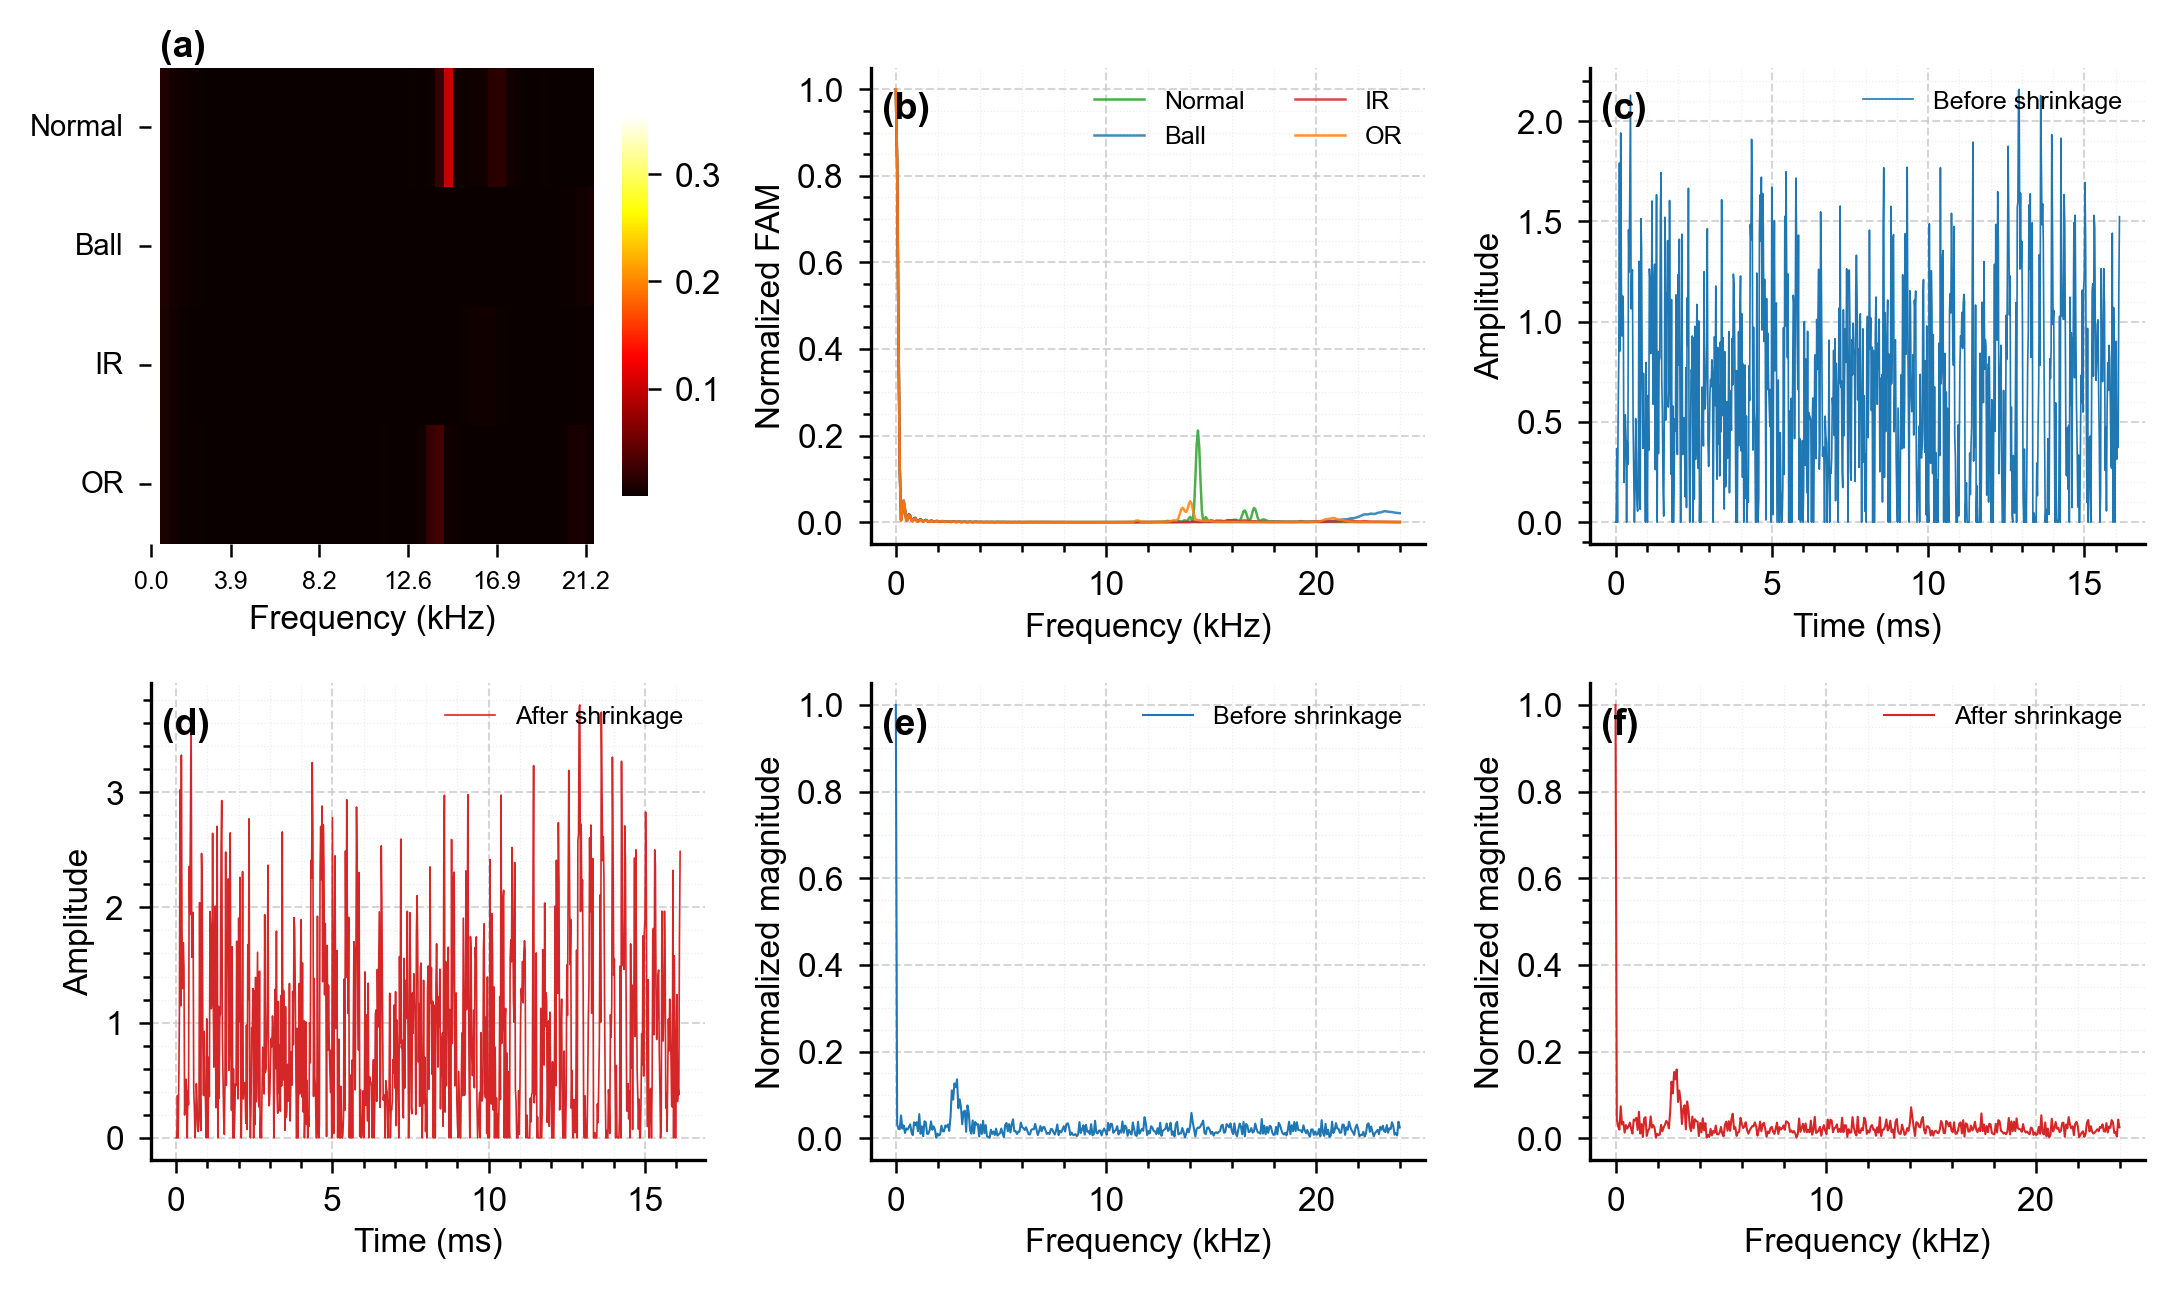

FAM与Shrinkage分析图已保存!


In [14]:
# 第六板块修正: FAM频率激活映射 + Shrinkage前后对比
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.labelpad": 2.5,
    "legend.frameon": False,
    "figure.dpi": 300
})

base_path = r'E:\EI会议2026四月\4.2故障诊断噪声'
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sampling_rate = 48000
window_size = 1024
n_class = 4
class_names = ['Normal', 'Ball', 'IR', 'OR']

# 先单独提取Shrinkage前后特征(用一个batch即可)
model2.eval()
shrink_data = {}

with torch.no_grad():
    for xb, yb in train_loader_noisy:
        xb = xb.to(device)
        feat = model2.p1_0(xb)  # (B, 64, 775)
        shrink_out = model2.p3_0(feat)
        shrink_data['before'] = feat[0].cpu().numpy()       # (64, 775)
        shrink_data['after'] = (feat + shrink_out)[0].cpu().numpy()
        break

print(f"Shrinkage前特征: {shrink_data['before'].shape}")
print(f"Shrinkage后特征: {shrink_data['after'].shape}")

# FAM计算
def compute_fam(model, dataloader, n_class, device):
    model.eval()
    feat_len = 775  # 1024 - 250 + 1
    freq_len = feat_len // 2 + 1

    fam_sum = torch.zeros(n_class, freq_len).to(device)
    fam_count = torch.zeros(n_class).to(device)

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            feat = model.p1_0(xb)
            output = model(xb)
            pred = torch.argmax(output, dim=1)

            fc_weight = model.p4.weight.data

            feat_s = feat + model.p3_0(feat)
            feat_s = model.p3_1(feat_s)

            for cls_id in range(n_class):
                mask = (pred == cls_id)
                if mask.sum() == 0:
                    continue
                cls_feat = feat_s[mask]
                for ch in range(10):
                    ps = torch.abs(torch.fft.rfft(cls_feat[:, ch, :], n=feat_len)) ** 2
                    ps = ps / (ps.mean(dim=-1, keepdim=True) + 1e-8)
                    w = fc_weight[cls_id, ch]
                    if w > 0:
                        fam_sum[cls_id] += (w * ps).sum(dim=0)
                fam_count[cls_id] += mask.sum().float()

    for cls_id in range(n_class):
        if fam_count[cls_id] > 0:
            fam_sum[cls_id] /= fam_count[cls_id]
    for cls_id in range(n_class):
        max_val = fam_sum[cls_id].max()
        if max_val > 0:
            fam_sum[cls_id] /= max_val

    return fam_sum.cpu().numpy()

print("计算FAM频率激活映射...")
fam = compute_fam(model2, train_loader_noisy, n_class, device)
print(f"FAM shape: {fam.shape}")

freq_axis_fam = np.fft.rfftfreq(775, d=1/sampling_rate) / 1000

# 可视化: 2行3列
def setup_ax(ax, xlabel, ylabel, label_id):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.8)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.3, color='#DDDDDD', alpha=0.5)
    ax.minorticks_on()
    ax.set_axisbelow(True)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.text(0.02, 0.95, label_id, transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='top')

fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.2))
axes_flat = axes.flatten()
labels_abc = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# (a) FAM热力图
ax = axes_flat[0]
n_freq_bins = 50
bin_size = fam.shape[1] // n_freq_bins
fam_binned = np.zeros((n_class, n_freq_bins))
freq_labels = []
for i in range(n_freq_bins):
    start = i * bin_size
    end = min((i + 1) * bin_size, fam.shape[1])
    fam_binned[:, i] = fam[:, start:end].mean(axis=1)
    freq_labels.append(f'{freq_axis_fam[start]:.1f}')

sns.heatmap(fam_binned, ax=ax, cmap='hot', cbar=True,
            cbar_kws={'shrink': 0.8, 'aspect': 15},
            yticklabels=class_names, xticklabels=False)
xtick_pos = np.linspace(0, n_freq_bins-1, 6).astype(int)
ax.set_xticks(xtick_pos)
ax.set_xticklabels([freq_labels[i] for i in xtick_pos], fontsize=6)
ax.set_xlabel('Frequency (kHz)', fontsize=8)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=7, rotation=0)
ax.text(0.02, 1.08, labels_abc[0], transform=ax.transAxes,
        fontsize=9, fontweight='bold', va='top')

# (b) 各类FAM曲线
ax = axes_flat[1]
colors_cls = {0: '#2ca02c', 1: '#1f77b4', 2: '#d62728', 3: '#ff7f0e'}
for cls_id in range(n_class):
    ax.plot(freq_axis_fam, fam[cls_id], color=colors_cls[cls_id],
            linewidth=0.6, alpha=0.85, label=class_names[cls_id])
setup_ax(ax, 'Frequency (kHz)', 'Normalized FAM', labels_abc[1])
ax.legend(loc='upper right', fontsize=6, ncol=2)

# Shrinkage前后: 选第10个通道
ch = 10
feat_before = shrink_data['before']
feat_after = shrink_data['after']
t_feat = np.arange(feat_before.shape[1]) / sampling_rate * 1000

# (c) Shrinkage前 时域
ax = axes_flat[2]
ax.plot(t_feat, feat_before[ch], color='#1f77b4', linewidth=0.4)
setup_ax(ax, 'Time (ms)', 'Amplitude', labels_abc[2])
ax.legend(['Before shrinkage'], loc='upper right', fontsize=6)

# (d) Shrinkage后 时域
ax = axes_flat[3]
ax.plot(t_feat, feat_after[ch], color='#d62728', linewidth=0.4)
setup_ax(ax, 'Time (ms)', 'Amplitude', labels_abc[3])
ax.legend(['After shrinkage'], loc='upper right', fontsize=6)

# (e) Shrinkage前 频域
ax = axes_flat[4]
freq_feat = np.fft.rfftfreq(feat_before.shape[1], d=1/sampling_rate) / 1000
fft_before = np.abs(np.fft.rfft(feat_before[ch]))
fft_before = fft_before / (fft_before.max() + 1e-8)
ax.plot(freq_feat, fft_before, color='#1f77b4', linewidth=0.5)
setup_ax(ax, 'Frequency (kHz)', 'Normalized magnitude', labels_abc[4])
ax.legend(['Before shrinkage'], loc='upper right', fontsize=6)

# (f) Shrinkage后 频域
ax = axes_flat[5]
fft_after = np.abs(np.fft.rfft(feat_after[ch]))
fft_after = fft_after / (fft_after.max() + 1e-8)
ax.plot(freq_feat, fft_after, color='#d62728', linewidth=0.5)
setup_ax(ax, 'Frequency (kHz)', 'Normalized magnitude', labels_abc[5])
ax.legend(['After shrinkage'], loc='upper right', fontsize=6)

plt.tight_layout(pad=0.5, h_pad=1.2, w_pad=0.8)

fig.savefig(os.path.join(base_path, 'fam_shrinkage_analysis.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(base_path, 'fam_shrinkage_analysis.pdf'),
            bbox_inches='tight', facecolor='white')
plt.show()
print("FAM与Shrinkage分析图已保存!")